In [ ]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh,w_sat
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
import GB84_eqs # import f as flux, rho_m,flux_2
import updraft_emmanuel
#from updraft_emmanuel import w_parcel 
import new_rainfall_scheme as nr
import top_outflow as outflow

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Loading the data

Choose the time interval for which the model is to be run.

In [ ]:
#time to check
slice_str = "2024-07-04T00:00:00, 2024-07-06T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


Read the data which are to be used as inputs. The existing code uses a combined dataset from ERA5 surface values and ERA5 atmospheric profiles. The surface variables include the temperature, pressure, dew point temperature and vapor specific humidity and the profiles are of temperature,pressure and vapor specific humidity. Then, only the data corresponding to the desired time interval are selected.

In [ ]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))

Storing the time values and the timestep.

In [ ]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

In [ ]:
T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [ ]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


In [ ]:
rain_std = rain_rate.rolling(time=10, center=True).std()
rain_std = rain_std.dropna(dim='time')
rain_class = xr.zeros_like(rain_std)

# Stratiform: std > 0 and < 1.5

# Initialize classification by no rain = 0 where std == 0, else NaN
rain_class = xr.where(rain_std == 0, 0, np.nan)

# Assign stratiform = 1 where 0 < std <= 1.5
rain_class = xr.where((rain_std > 0) & (rain_std <= 1.5), 1, rain_class)

# Assign convective = 2 where std > 1.5
rain_class = xr.where(rain_std > 1.5, 2, rain_class)

# Optionally convert to integer
rain_class = rain_class.astype(int)

mask = (rain_class == 2)
mask_2 = (rain_class == 1)
# Get the indexes of True values along the 'time' dimension
indexes_conv = np.where(mask)[0]
indexes_strat = np.where(mask_2)[0]

## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [ ]:
rows = T_air.shape[0]
cols = T_air.shape[1]

Creating empty arrays (either of size (time,height) or (time)) for storing the model outputs. *temp_parcel* is the parcel temperature profile resulting by solving the thermodynamic equations implemented in the model, while *T_v_moist* and *q_v_parcel* are the resulting virtual temperature and moisture profiles of the parcel. *p_s*, *T_s* and *lcl_index* are the pressure, temperature and index at the LCL level. All the other arrays serve as the expansion of the current environmental profiles by 1 (time,height+1), so that the exact values of the meteorological variables at the LCL are stored. 

In [ ]:
T_arr = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
air_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


Implementing the model functions to calculate the temperature and humidity profiles.

1. Using the *profiles_and_cloud_heights.py*, the parcel temperature profile is calculated, as well as the LCL variables of interest.
2. Using the *interpolation_lcl.py*, all the parcel and environmental profiles are updated so that we have exact values for all the meteorological
   variables of interest at the LCL.
3. With *profiles_and_cloud_heights.py* parcel humidity and virtual temperature profiles are calculated. 

In [ ]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

theta_type = 'theta_e_reversible'       #choose which approach to follow for the conserved potential temperature

for i in range(0,T_air.shape[0]):
    #print(i)
    #calculating the profiles
    q_t = w_sat(T_d[i],p_air[i])
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i],temp_parcel[i,:],int(lcl_index[i]),theta_type=theta_type)

In [ ]:
lcl_index

array([2., 2., 2., 2., 2., 2., 3., 3., 4., 4., 4., 4., 4., 3., 3., 4., 4.,
       4., 3., 3., 3., 2., 2., 2.])

In [ ]:
negs = (q_v_parcel < 0).sum()
print(f"Number of negative values in q_l_new: {negs}")

Number of negative values in q_l_new: 0


Calculate the environmental virtual temperature profiles

In [ ]:
T_v_env = air_temp_new*(1+0.61*q_v_new)

### Cloud Heights

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [ ]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

In [ ]:
LFC_index

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 2.],
       [1., 2.],
       [1., 2.],
       [1., 3.],
       [1., 3.],
       [1., 4.],
       [1., 4.],
       [1., 4.],
       [1., 4.],
       [1., 4.],
       [1., 3.],
       [1., 3.],
       [1., 4.],
       [1., 4.],
       [1., 4.],
       [1., 3.],
       [1., 3.],
       [1., 5.],
       [1., 2.],
       [1., 2.],
       [1., 2.]])

Finding the cloud top height and pressure and the resulting cloud depth, again by calling *profiles_and_cloud_heights.py*.

In [ ]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel[i])

In [ ]:
Z_c

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       2.91512339e+03, 5.01583408e+03, 7.83818652e+03, 8.01230856e+03,
       7.90187897e+03, 1.05992107e+02, 4.29695291e+03, 7.03848989e+03,
       5.65320950e+03, 3.17754926e+03, 1.00000000e+00, 1.04375157e+02,
       2.73407714e+03, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00])

Updating the parcel profiles of temperature and humidity, this time taking entrainment into account 

In [ ]:
#from profiles_and_cloud_heights import profiles_with_entrainment
T_parcel_new = np.zeros((rows,cols+1)) 
q_t_parcel_new = np.zeros((rows,cols+1))
Theta_air = np.zeros((rows,cols+1))
for i in range(0,rows):
    print(i)
    #if Z_c[i] <= 100:
        #T_parcel_new[i] = 1*temp_parcel[i]
        #q_t_parcel_new[i] = 1*q_v_new[i]
    #else:
    entrainment_rate = min(0.001,1/Z_c[i])     #Siebesma et al. (2003)
    T_parcel_new[i],q_t_parcel_new[i] = profiles.calculate_profiles_with_entrainment(T_s[i], T_d[i], air_temp_new[i], temp_parcel[i], p_s[i], p_new[i], q_v_new[i], Z_new[i,], int(lcl_index[i]), entrainment_rate, theta_type)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


In [ ]:
Z_c[2]

1.0

index_plot = 105
plt.plot(T_parcel_new[index_plot],p_new[index_plot])
plt.plot(temp_parcel[index_plot],p_new[index_plot])
plt.plot(air_temp_new[index_plot],p_new[index_plot])
#plt.plot(Theta_air[index_plot],p_new[index_plot])
plt.gca().invert_yaxis()
#plt.ylim(100000,70000)
#plt.xlim(220,350)
plt.axhline(p_s[index_plot],color='red')
plt.axhline(p_t[index_plot],color='blue')
#plt.axhline(Z_new[16,int(lcl_index[16])],color='red')
#plt.axhline(Z_t_new[6],color='red')

q_t_parcel_new[index_plot]
plt.scatter(q_t_parcel_new[index_plot],p_new[index_plot])
plt.scatter(q_v_new[index_plot],p_new[index_plot])
#plt.xlim(0,0.02)
plt.gca().invert_yaxis()

In [ ]:
q_l_new = np.zeros((rows,cols+1))
q_v_parcel_new = 1*q_v_parcel
for i in range(0,rows):
    entrainment_rate = min(0.001,1/Z_c[i]) 
    q_l_new[i],q_v_parcel_new[i] = profiles.calculate_humidity_profiles_with_entrainment(q_t_parcel_new[i],p_new[i],T_parcel_new[i],T_d[i],int(lcl_index[i]),Z_new[i],q_v_new[i],entrainment_rate,theta_type=theta_type)

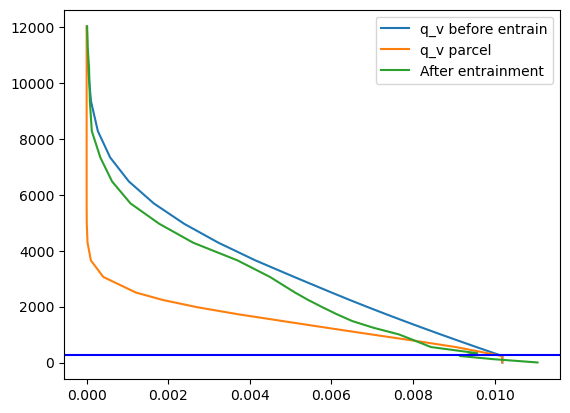

In [ ]:
index = 23
plt.plot(q_v_parcel[index],Z_new[index],label='q_v before entrain')
#plt.plot(q_l_new[index],Z_new[index],label='q_v air')
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_v parcel')
plt.plot(q_v_new[index], Z_new[index], label='After entrainment')
#plt.plot(w_sat(T_d[index],p_new[index]) - q_v_parcel[index], Z_new[index], label='After entrainment')  # mark LCLq_v_parcel[index], Z_new[index], label='After entrainment')
#plt.axhline(Z_new[index, int(lcl_index[index])], color='red')  # mark LCL
plt.axhline(Z_t[index], color='blue')
#plt.axhline(Z_t_new[index], color='green')
plt.legend()

In [ ]:
w_sat(T_parcel_new[index,int(lcl_index[index])+1],p_new[index,int(lcl_index[index])+1]) - 1/Z_c[index]*(Z_new[index,int(lcl_index[index])+1] - Z_new[index,int(lcl_index[index])])*(q_v_parcel_new[index,int(lcl_index[index])] - q_v_parcel[index,int(lcl_index[index])])

0.009826392550386894

In [ ]:
w_sat(T_parcel_new[index,int(lcl_index[index])+1],p_new[index,int(lcl_index[index])+1])

0.009826392550386894

In [ ]:
q_t_parcel_new[index,int(lcl_index[index])+4]

0.009317290450033723

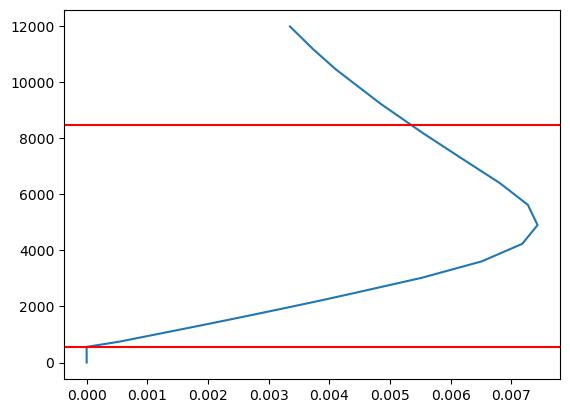

In [ ]:
#plt.plot(q_v_new[10],Z_new[10])
#plt.plot(q_v_parcel_new[5],Z_new[5])
plt.plot(q_l_new[12],Z_new[12])
plt.axhline(Z_new[12,int(lcl_index[12])],color='red')
#plt.axhline(Z_new[10,int(LFC_index[10,1])],color='red')
plt.axhline(Z_t[12],color='red')
#plt.plot(q_v_parcel[10],Z_new[10])

In [ ]:
q_v_parcel_new[2] - q_v_parcel[2]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -4.75181379e-05,
       -3.40978969e-04, -8.42344747e-04, -1.57884424e-03, -2.46320382e-03,
       -3.35632197e-03, -4.17235795e-03, -4.89758111e-03, -5.40533702e-03,
       -5.69078252e-03, -5.65129800e-03, -4.97910459e-03, -4.04981027e-03,
       -3.09833971e-03, -2.21383649e-03, -1.44866936e-03, -8.43191117e-04,
       -4.20507604e-04, -1.71450291e-04, -5.34908598e-05, -2.61583804e-05,
       -1.13786304e-05])

Calculating the new parcel virtual temperature profile after considering entrainment 

In [ ]:
if theta_type=='theta_e' or theta_type=='GB84':
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new)
else:
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new- q_l_new)

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [ ]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist_new[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

Finding the cloud top height and pressure and the resulting cloud depth, again by calling *profiles_and_cloud_heights.py*.

In [ ]:
#empty arrays for storing the outputs
Z_c_new = np.zeros(rows)
Z_t_new = np.zeros(rows)
p_t_new = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c_new[i],Z_t_new[i],p_t_new[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist_new[i],T_v_env[i],T_parcel_new[i])

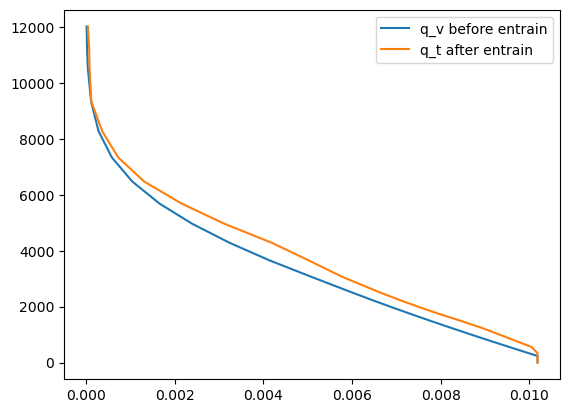

In [ ]:
plt.plot(q_v_parcel[index],Z_new[index],label='q_v before entrain')
#plt.plot(q_v_parcel[index],Z_new[index])
#plt.plot(q_v_new[index],Z_new[index])
plt.plot(q_t_parcel_new[index],Z_new[index],label='q_t after entrain')
#plt.plot(q_v_new[index],Z_new[index])
#plt.plot(q_v_parcel_new[index],Z_new[index])
#plt.plot(q_l_new[index],Z_new[index])
#plt.axhline(y=Z_new[index,int(lcl_index[index+1])],color='blue')
#plt.axhline(y=Z_t[index],color='green')
#plt.axhline(y=Z_t_new[index],color='red')
plt.legend()

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel updraft velocity profile by calling the *updraft_emmanuel.py*. To do so, we have to first find the index of cloud top height. 

In [ ]:
#import updraft_emmanuel

w_parcel_max= np.zeros(rows)
buoyancy_arr = np.zeros(rows)
for i in range(0,rows):
    #print(i)
    if Z_t_new[i] == 0 or Z_c_new[i] <= 100:
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new[i] - Z_new[i]) <= 0)
         if i == 50:
            print(top_index)
    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(p_new[i],T_v_moist_new[i],T_v_env[i],LFC_index[i,1],Z_new[i],top_index)

[0.00847072 0.02739897]
[0.01166185 0.02739897 0.02817088 0.02898754 0.02985296 0.03077166]
[0.01683546 0.02739897 0.02817088 0.02898754 0.02985296 0.03077166
 0.0317487 ]
[0.02181572 0.02739897 0.02817088 0.02898754]
[0.01285315 0.02666825 0.02739897 0.02817088]
[0.02480845 0.02739897 0.02817088 0.02898754 0.02985296]
[0.01972884 0.02739897 0.02817088 0.02898754 0.02985296]
[0.02035419]


from constants import R_dry
def w_parcel(p,T_v_moist,T_v_env,lfc_index,p_t,top_index):

    """
    the scheme for calculating the maximum updraft velocity (Emanuel 1991)

    Parameters:
        p: pressure profile  [Pa]"
        T_v_moist: parcel virtual temperature profile [K]"
        T_env: environment virtual temperature profile  [K]"
        lfc_index: index of the LFC
        top_index: index of the top of the cloud

    Returns:
        w_parcel_max: maximum updraft velocity [m/s]
        CAPE: convective available potential energy
    """
    
    if top_index>1 and top_index>int(lfc_index):
    #implementation of the CAPE equation and integration
        delta_ln_p = -np.diff(np.log(p[int(lfc_index):top_index+1]))
        
        buoyancy = R_dry * (T_v_moist - T_v_env)[int(lfc_index):top_index]
        print(buoyancy)
        CAPE = np.sum(buoyancy * delta_ln_p)
        w_parcel_max = np.sqrt(2 * CAPE)
    else:
        w_parcel_max = 0
        CAPE = 0
    return w_parcel_max,CAPE
if Z_t_new[138] == 0:
        top_index = 0
else:
         top_index = np.argmax((Z_t_new[138] - Z_new[138]) <= 0)
print(top_index)
w_parcel(p_new[138],T_v_moist_new[138],T_v_env[138],LFC_index[138,1],p_t_new[138],top_index)

In [ ]:
n_nans = np.isnan(q_t_parcel_new).sum()
print(f"Number of NaNs in q_l_new: {n_nans}")

Number of NaNs in q_l_new: 0


### State calculation and update

Calculating the state evolution with time. The moisture flux in the cloud system is calculated using the *GB84.py* to find the amount of condensed water, while the outflow is consists of the water amount converted to rain (calculated by *autoconversion_rate.py*) and the cloud droplets caught by the updraft (*top_outflow.py*).

In [ ]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t_new[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new[i] - Z_new[i]) <= 0)

    w_avg = w_parcel_max[i]/2
    rho = GB84_eqs.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    print(rho)
    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = GB84_eqs.flux_2(rho,w_avg,q_l_new[i],int(lcl_index[i]),top_index)

    if i<rows-1:
        if X[i]/Z_c_new[i] > 3e-3:        #capping the X values so that they don't abnormally high
            X[i] = 3e-3*Z_c_new[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.cloud_water_autoconoversion_rate(X[i],Z_c_new[i],thresh)*dt_seconds[i] - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        #print(outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i])
        X[i+1] = max(0,X[i+1])

0
0.5955420229266708
1
0.5952998717322516
2
0.593542190982231
3
1.1880545032153407
4
1.1873694453479668
5
1.184774731793641
6
1.1757106532839594
7
1.1643619610746736
8
1.146297562684842
9
1.1279418242431094
10
1.0731874161550743
11
1.0674420875660446
12
1.1048670496438018
13
1.1708823713287142
14
1.1342654533037442
15
1.0902655456662615
16
1.0932305021768975
17
1.141233336481593
18
1.164871558858582
19
1.1694919968178685
20
0.5895563686875929
21
1.1887216853380265
22
1.1917138596421943
23
1.1979973645769402


In [ ]:
q_l_new

array([[0.00000000e+00, 0.00000000e+00, 1.21430643e-17, 2.43260301e-04,
        6.67161303e-04, 1.21463407e-03, 1.86747959e-03, 2.62105775e-03,
        3.42899102e-03, 4.21566508e-03, 4.92838720e-03, 5.56106131e-03,
        6.09178611e-03, 6.49028728e-03, 5.69300524e-03, 4.49459390e-03,
        3.54604997e-03, 2.60476213e-03, 1.58036623e-03, 7.07025766e-04,
        3.59853036e-04, 1.19061621e-04, 6.88205372e-05, 6.02507136e-05,
        4.19283718e-05],
       [0.00000000e+00, 0.00000000e+00, 6.93889390e-18, 2.37291326e-04,
        7.22048697e-04, 1.29988882e-03, 1.90968883e-03, 2.51776744e-03,
        3.08423547e-03, 3.59074104e-03, 4.13533019e-03, 4.60815022e-03,
        4.96107896e-03, 5.00301549e-03, 4.20907680e-03, 3.60792634e-03,
        3.12493869e-03, 2.13540729e-03, 1.11822210e-03, 6.00890102e-04,
        3.19959609e-04, 1.48362894e-04, 7.36784661e-05, 5.35727692e-05,
        3.63395608e-05],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.10406401e-04,
        7.3926

#### Rainfall rates

Calculating the precipitation rate in the ground. First, the rate of rainfall exiting the cloud is found by calling *autoconversion_rate.py*. Then, given this rainfall rate, we assume and calculate (*new_rainfall_scheme.py*) a rain droplet size distribution and we estimate the amount that survives evaporation and reaches the ground as precipitation.

In [ ]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    print(i)
    rho = GB84_eqs.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    R[i] = ar.cloud_water_autoconoversion_rate(X[i],Z_c_new[i],thresh)
    if R[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        #print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(T_parcel_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c_new[i],w_parcel_max[i]/2*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


In [ ]:
w_parcel_max_old= np.zeros(rows)
for i in range(0,rows):
    #print(i)
    if Z_t[i] == 0 or Z_c[i] <= 100:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z[i]) <= 0)
         if i == 50:
            print(top_index)
    w_parcel_max_old[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(p_new[i],T_v_moist[i],T_v_env[i],LFC_index[i,1],Z_new[i],top_index)

#import new_rainfall_scheme as nr
f_arr_old = np.zeros(rows)
X_old =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)

    w_avg = w_parcel_max_old[i]/2
    rho = GB84_eqs.rho_m(T_s[i],temp_parcel[i,top_index],p_s[i],p_t[i])
    print(rho)
    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr_old[i] = 0
    else:
        f_arr_old[i] = GB84_eqs.flux_2(rho,w_avg,w_sat(T_d[i],p_new[i,0]) - q_v_parcel,int(lcl_index[i]),top_index)

    if i<rows-1:
        if X_old[i]/Z_c[i] > 3e-3:        #capping the X values so that they don't abnormally high
            X_old[i] = 3e-3*Z_c[i]

    #state update
        X_old[i+1] = X_old[i] +f_arr_old[i]*dt_seconds[i] - ar.cloud_water_autoconoversion_rate(X_old[i],Z_c[i],thresh)*dt_seconds[i] - outflow.calculate_water_top_outflow(X_old[i],top_index,Z_b[i],Z_new[i],w_parcel_max_old[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        #print(outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i])
        X_old[i+1] = max(0,X_old[i+1])
# empty arrays for storing the rainfall rates and the size distribution parameters

R_old = np.zeros(rows)  #rainfall rate at the cloud base
P_old = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    print(i)
    rho = GB84_eqs.rho_m(T_s[i],temp_parcel[i,top_index],p_s[i],p_t[i])
    R_old[i] = ar.cloud_water_autoconoversion_rate(X_old[i],Z_c[i],thresh)
    if R_old[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P_old[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R_old[i], alpha, w_parcel_max_old[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        #print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(temp_parcel[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c[i],w_parcel_max_old[i]/2*100).calculate_evaporation_critical_diameter()
        P_old[i] = nr.ground_precipitation_rate(R_old[i], mu_result, Lambda_result, D_critical*100,w_parcel_max_old[i]/2*100,alpha)

[0.01933763 0.02739897 0.02817088 0.02898754 0.02985296 0.03077166
 0.0317487  0.03278982 0.06899287]
[0.00847072 0.02739897 0.02817088 0.02898754 0.02985296 0.03077166
 0.0317487  0.03278982 0.06899287 0.07410797 0.08004271 0.08701138
 0.09531018]
[0.01166185 0.02739897 0.02817088 0.02898754 0.02985296 0.03077166
 0.0317487  0.03278982 0.06899287 0.07410797 0.08004271 0.08701138
 0.09531018 0.10536052 0.11778304 0.13353139]
[0.01683546 0.02739897 0.02817088 0.02898754 0.02985296 0.03077166
 0.0317487  0.03278982 0.06899287 0.07410797 0.08004271 0.08701138
 0.09531018 0.10536052 0.11778304 0.13353139]
[0.02181572 0.02739897 0.02817088 0.02898754 0.02985296 0.03077166
 0.0317487  0.03278982 0.06899287 0.07410797 0.08004271 0.08701138
 0.09531018 0.10536052 0.11778304 0.13353139]
[0.01285315 0.02666825 0.02739897 0.02817088 0.02898754 0.02985296
 0.03077166 0.0317487  0.03278982 0.06899287 0.07410797 0.08004271]
[0.02480845 0.02739897 0.02817088 0.02898754 0.02985296 0.03077166
 0.031748

In [ ]:
X - thresh*Z_c

array([-5.00000000e-04, -5.00000000e-04, -5.00000000e-04, -5.00000000e-04,
       -5.00000000e-04, -5.00000000e-04, -5.00000000e-04, -5.00000000e-04,
       -1.45756169e+00, -2.50791704e+00, -1.67735701e-01,  4.28910635e-01,
       -1.49180689e+00, -4.99960536e-02, -2.14847645e+00, -8.96706719e-02,
        1.99813506e-01, -1.15807494e+00, -5.00000000e-04, -5.21875784e-02,
       -1.36703857e+00, -5.00000000e-04, -5.00000000e-04, -5.00000000e-04])

In [ ]:
thresh*Z_c_new

array([5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 9.62878071e-02, 6.25226260e-01, 7.39177486e-01,
       4.09855433e-01, 5.00000000e-04, 3.21513842e-01, 5.71595712e-01,
       5.04403042e-01, 7.17832819e-02, 5.00000000e-04, 5.00000000e-04,
       5.00000000e-04, 5.00000000e-04, 5.00000000e-04, 5.00000000e-04])

In [ ]:
w_parcel_max_old

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        , 10.11562579, 19.01179113,
       31.4714998 , 33.22755635, 25.16283667,  0.        , 18.08922754,
       23.3080622 , 23.52000288, 14.45628782,  0.        ,  0.        ,
        5.86312506,  0.        ,  0.        ,  0.        ])

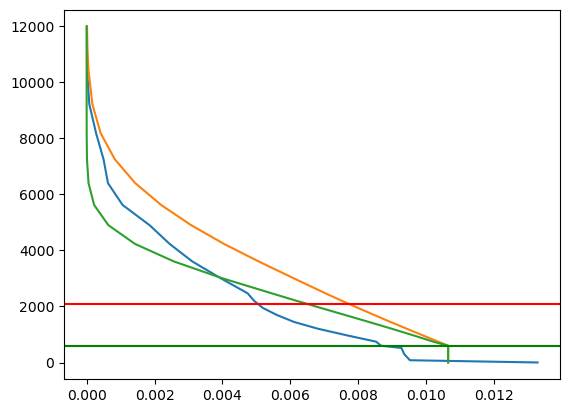

In [ ]:
index_max = np.argmax(Z_t_new)
plt.plot(q_v_new[index_max],Z_new[index_max])
plt.plot(q_v_parcel[index_max],Z_new[index_max])
plt.plot(q_v_parcel_new[index_max],Z_new[index_max])
plt.axhline(y=Z_t_new[index_max],color='red')
plt.axhline(y=Z_new[index_max,int(LFC_index[index_max,1])],color='green')

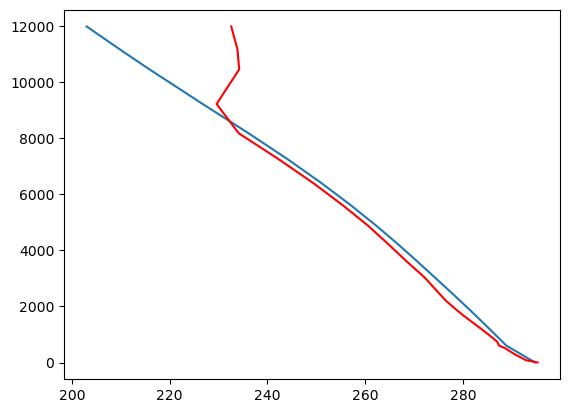

In [ ]:
plt.plot(T_v_moist[index_max],Z_new[index_max])
#plt.plot(T_v_moist_new[index_max],Z_new[index_max])
plt.plot(T_v_env[index_max],Z_new[index_max],color='red')

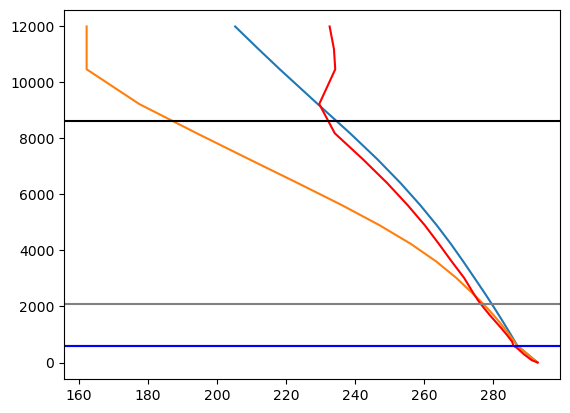

In [ ]:
plt.plot(temp_parcel[index_max],Z_new[index_max])
plt.plot(T_parcel_new[index_max],Z_new[index_max])
plt.plot(air_temp_new[index_max],Z_new[index_max],color='red')
plt.axhline(y=Z_new[index_max,int(LFC_index[index_max,1])],color='green')
plt.axhline(y=Z_new[index_max,int(lcl_index[index_max])],color='blue')
plt.axhline(y=Z_t[index_max],color='black')
plt.axhline(y=Z_t_new[index_max],color='gray')

In [ ]:
Z_c

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       2.91512339e+03, 5.01583408e+03, 7.83818652e+03, 8.01230856e+03,
       7.90187897e+03, 1.05992107e+02, 4.29695291e+03, 7.03848989e+03,
       5.65320950e+03, 3.17754926e+03, 1.00000000e+00, 1.04375157e+02,
       2.73407714e+03, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00])

## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

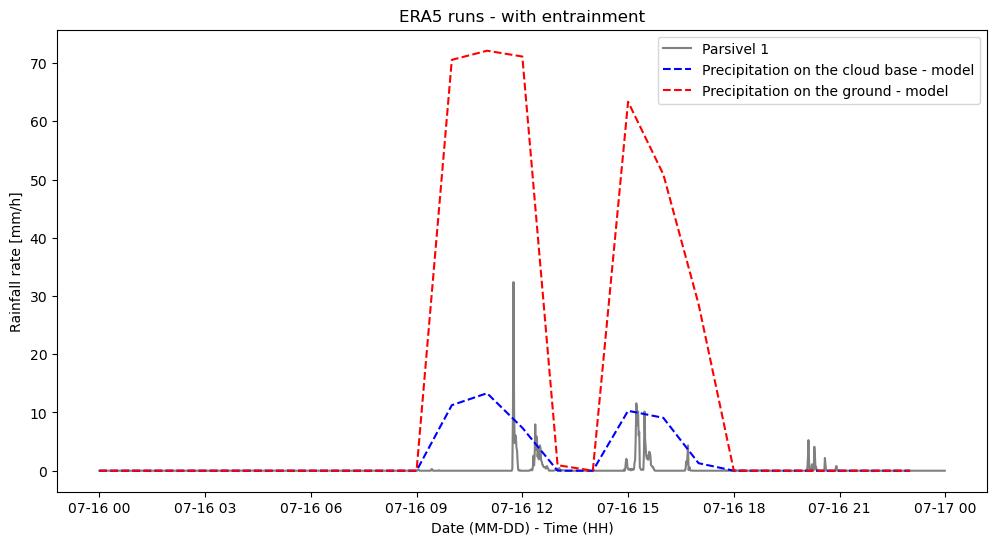

In [ ]:
plt.figure(figsize=(12,6))
plt.title('ERA5 runs - with entrainment')
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(rain_rate.time,rain_rate,color='grey',label='Parsivel 1')
plt.plot(time,R*3600,color='blue',linestyle='--',label='Precipitation on the cloud base - model')
plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')


plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

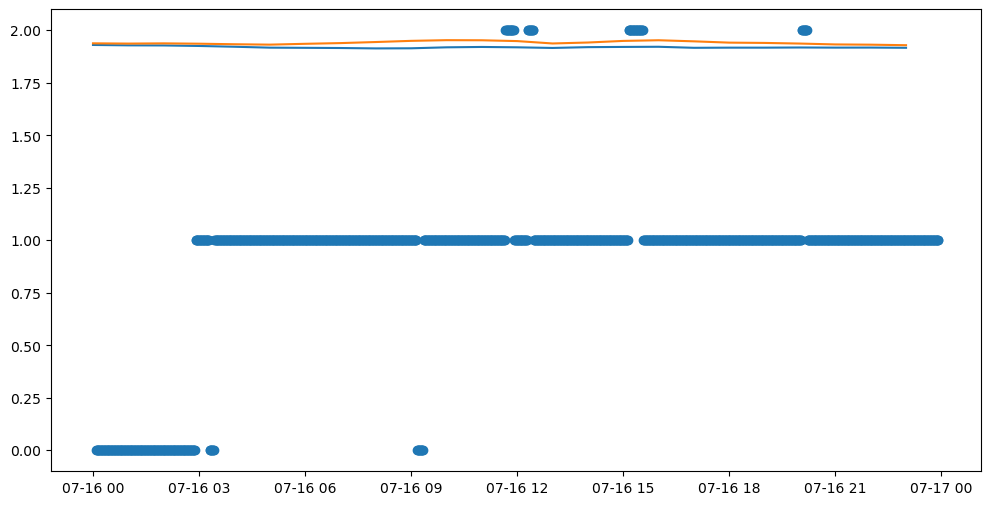

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(time,T_d/150)
plt.plot(time,air_temp_new[:,0]/150)
plt.scatter(rain_class.time,rain_class)

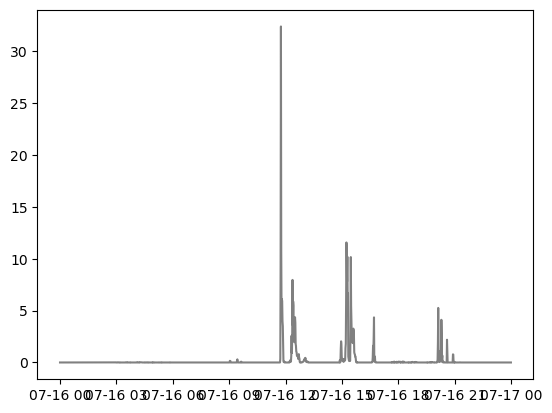

In [ ]:
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')

np.mean(air_temp_new[indexes_strat,0] - T_d[indexes_strat])

#### Virtual Temperature profiles at different times

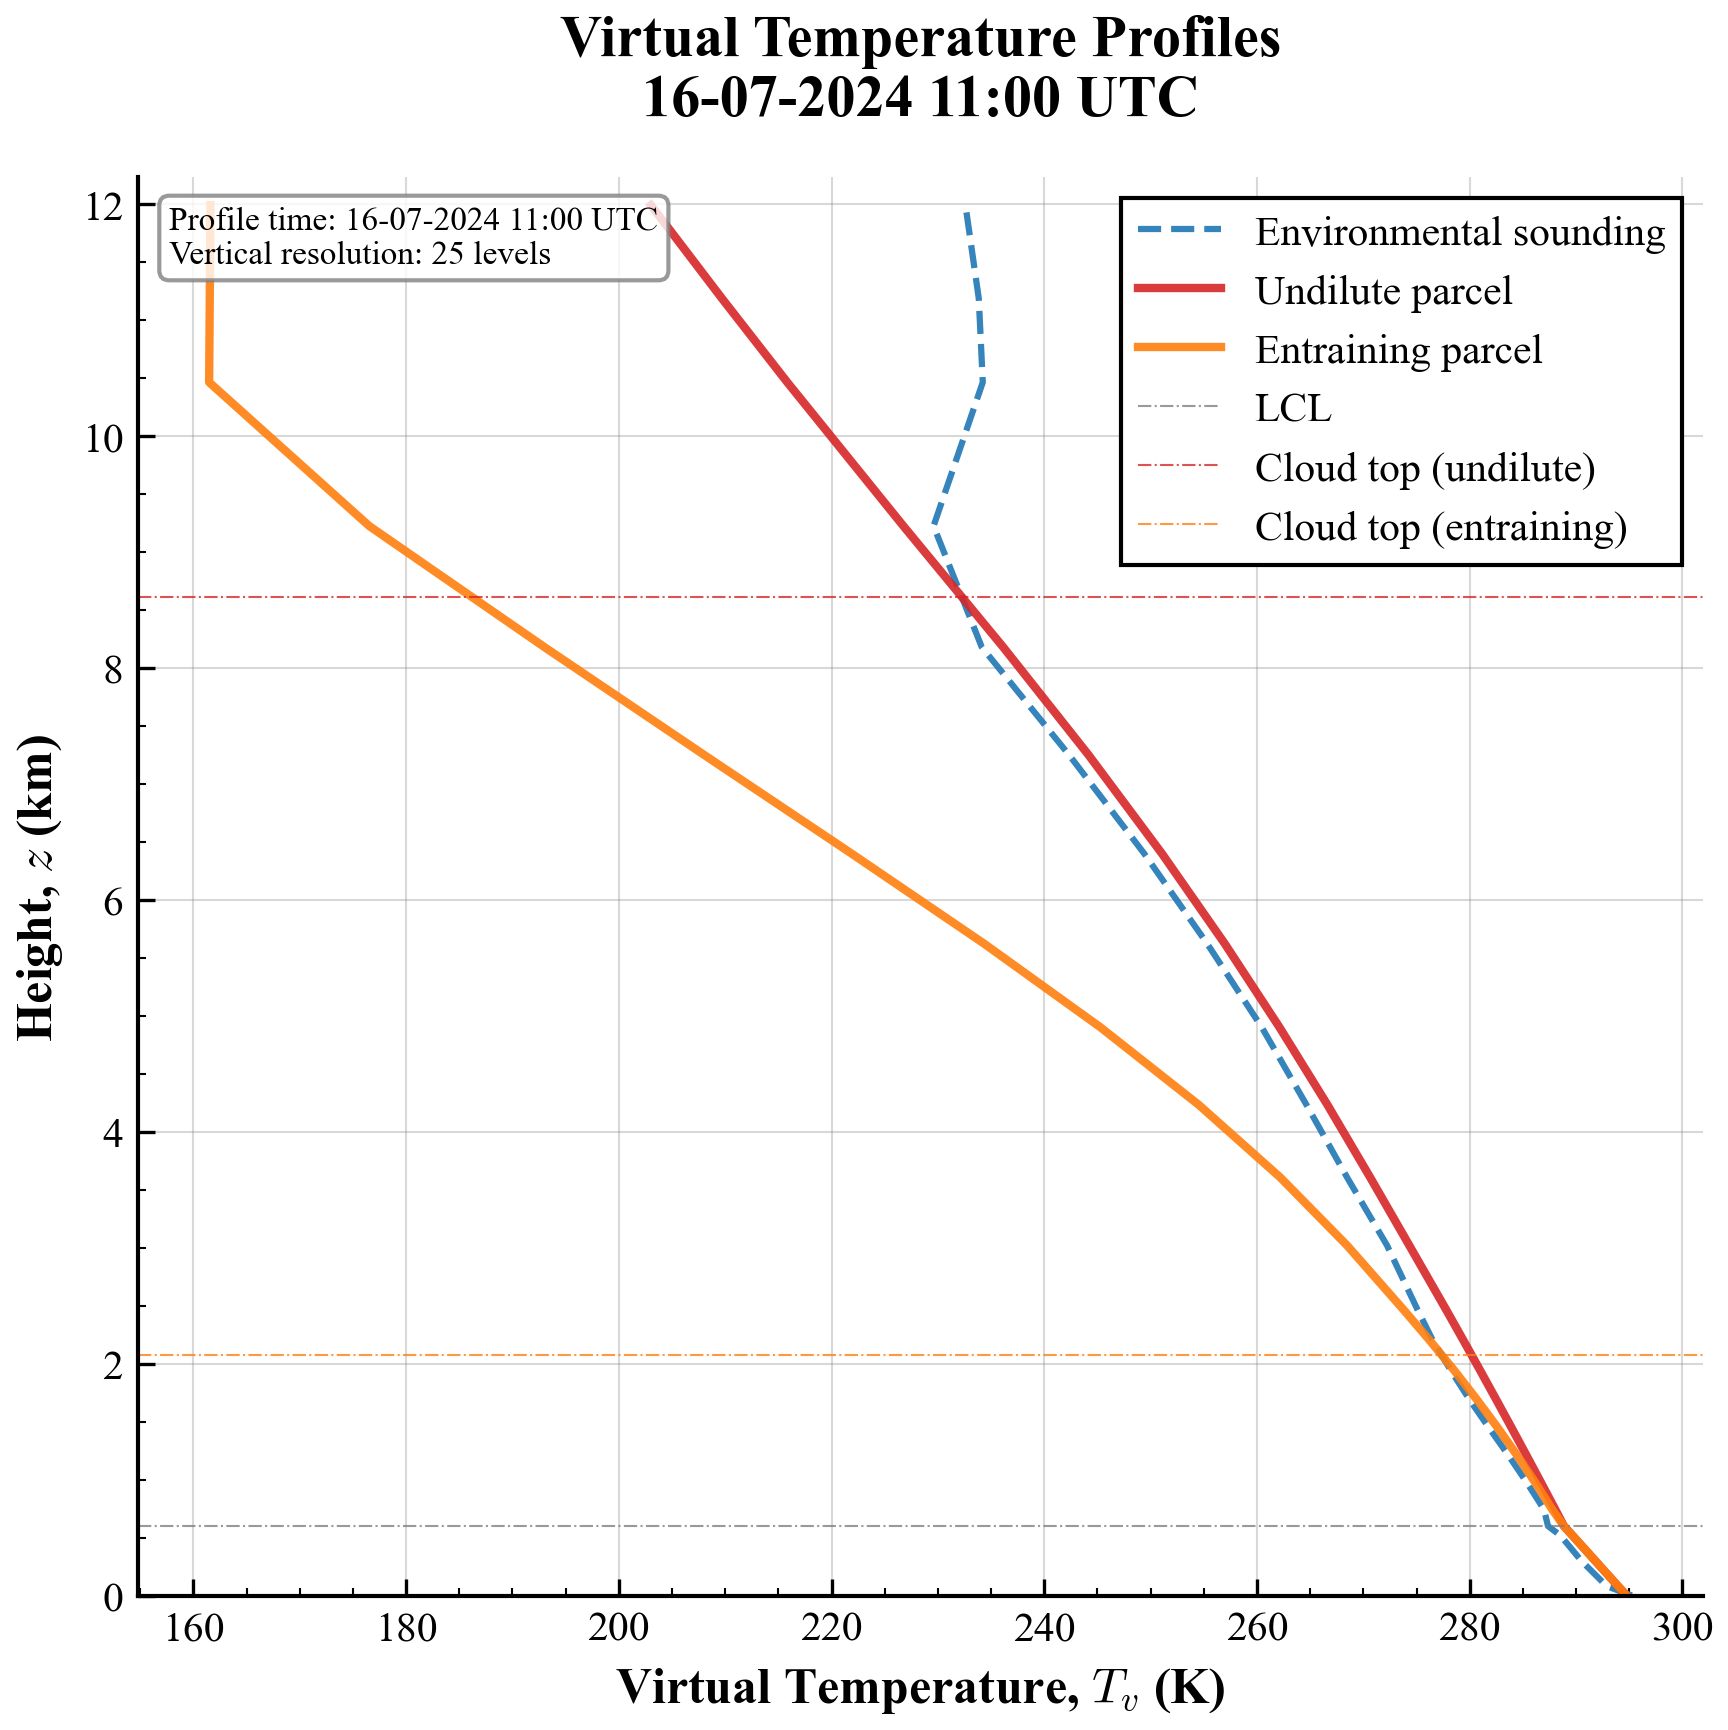

In [ ]:
index_2 = 11
import pandas as pd
import numpy as np

# Scientific publication-quality styling
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines
    'axes.linewidth': 1.0,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'xtick.minor.size': 2,
    'ytick.major.size': 4,
    'ytick.minor.size': 2,
    'xtick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.major.width': 0.8,
    'ytick.minor.width': 0.5,
    
    # Legend
    'legend.fontsize': 10,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with scientific aspect ratio
fig, ax = plt.subplots(figsize=(6, 6))  # Taller for atmospheric profiles

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Plot with scientific line styles and markers
line_ambient = ax.plot(T_v_env[index_2], Z_new[index_2]/1000,  # Convert to km
                      color=colors['ambient'], 
                      label='Environmental sounding',
                      linestyle='--', 
                      linewidth=1.5,
                      alpha=0.9)

line_dry = ax.plot(T_v_moist[index_2], Z_new[index_2]/1000,
                  color=colors['no_entrainment'], 
                  label='Undilute parcel',
                  linestyle='-', 
                  linewidth=2.0,
                  alpha=0.9)

line_entrain = ax.plot(T_v_moist_new[index_2], Z_new[index_2]/1000,
                      color=colors['with_entrainment'], 
                      label='Entraining parcel',
                      linestyle='-', 
                      linewidth=2.0,
                      alpha=0.9)

# Scientific axis labels with units
ax.set_xlabel('Virtual Temperature, $T_v$ (K)', fontweight='bold')
ax.set_ylabel('Height, $z$ (km)', fontweight='bold')

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')
ax.set_title(f'Virtual Temperature Profiles\n{timestamp_str}',
             fontweight='bold', pad=15)

# Scientific grid
ax.grid(True, alpha=0.3, linewidth=0.5, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Add horizontal reference lines with labels
lcl_line = ax.axhline(y=Z_new[index_2,int(lcl_index[index_2])]/1000, 
                     color='grey', linestyle='-.', linewidth=0.5, alpha=0.8,
                     label='LCL')

zt_line = ax.axhline(y=Z_t[index_2]/1000, 
                    color=colors['no_entrainment'], linestyle='-.', linewidth=0.5, alpha=0.8,
                    label='Cloud top (undilute)')

zt_new_line = ax.axhline(y=Z_t_new[index_2]/1000, 
                        color=colors['with_entrainment'], linestyle='-.', linewidth=0.5, alpha=0.8,
                        label='Cloud top (entraining)')

# Set axis limits with some padding for scientific presentation
temp_range = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
              np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding = (temp_range[1] - temp_range[0]) * 0.05
ax.set_xlim(temp_range[0] - temp_padding, temp_range[1] + temp_padding)

height_max = Z_new[index_2].max()/1000
ax.set_ylim(0, height_max * 1.02)

# Scientific legend positioning - now includes horizontal lines
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5,
                  ncol=1)  # Single column for cleaner look

# Add subtle background for better contrast
#ax.set_facecolor('#fafafa')

# Professional tick formatting
ax.ticklabel_format(style='plain', axis='x')
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed
from matplotlib.ticker import ScalarFormatter
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

plt.tight_layout()

# Optional: Add metadata text box for scientific context
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

# Show the plot
plt.show()

# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

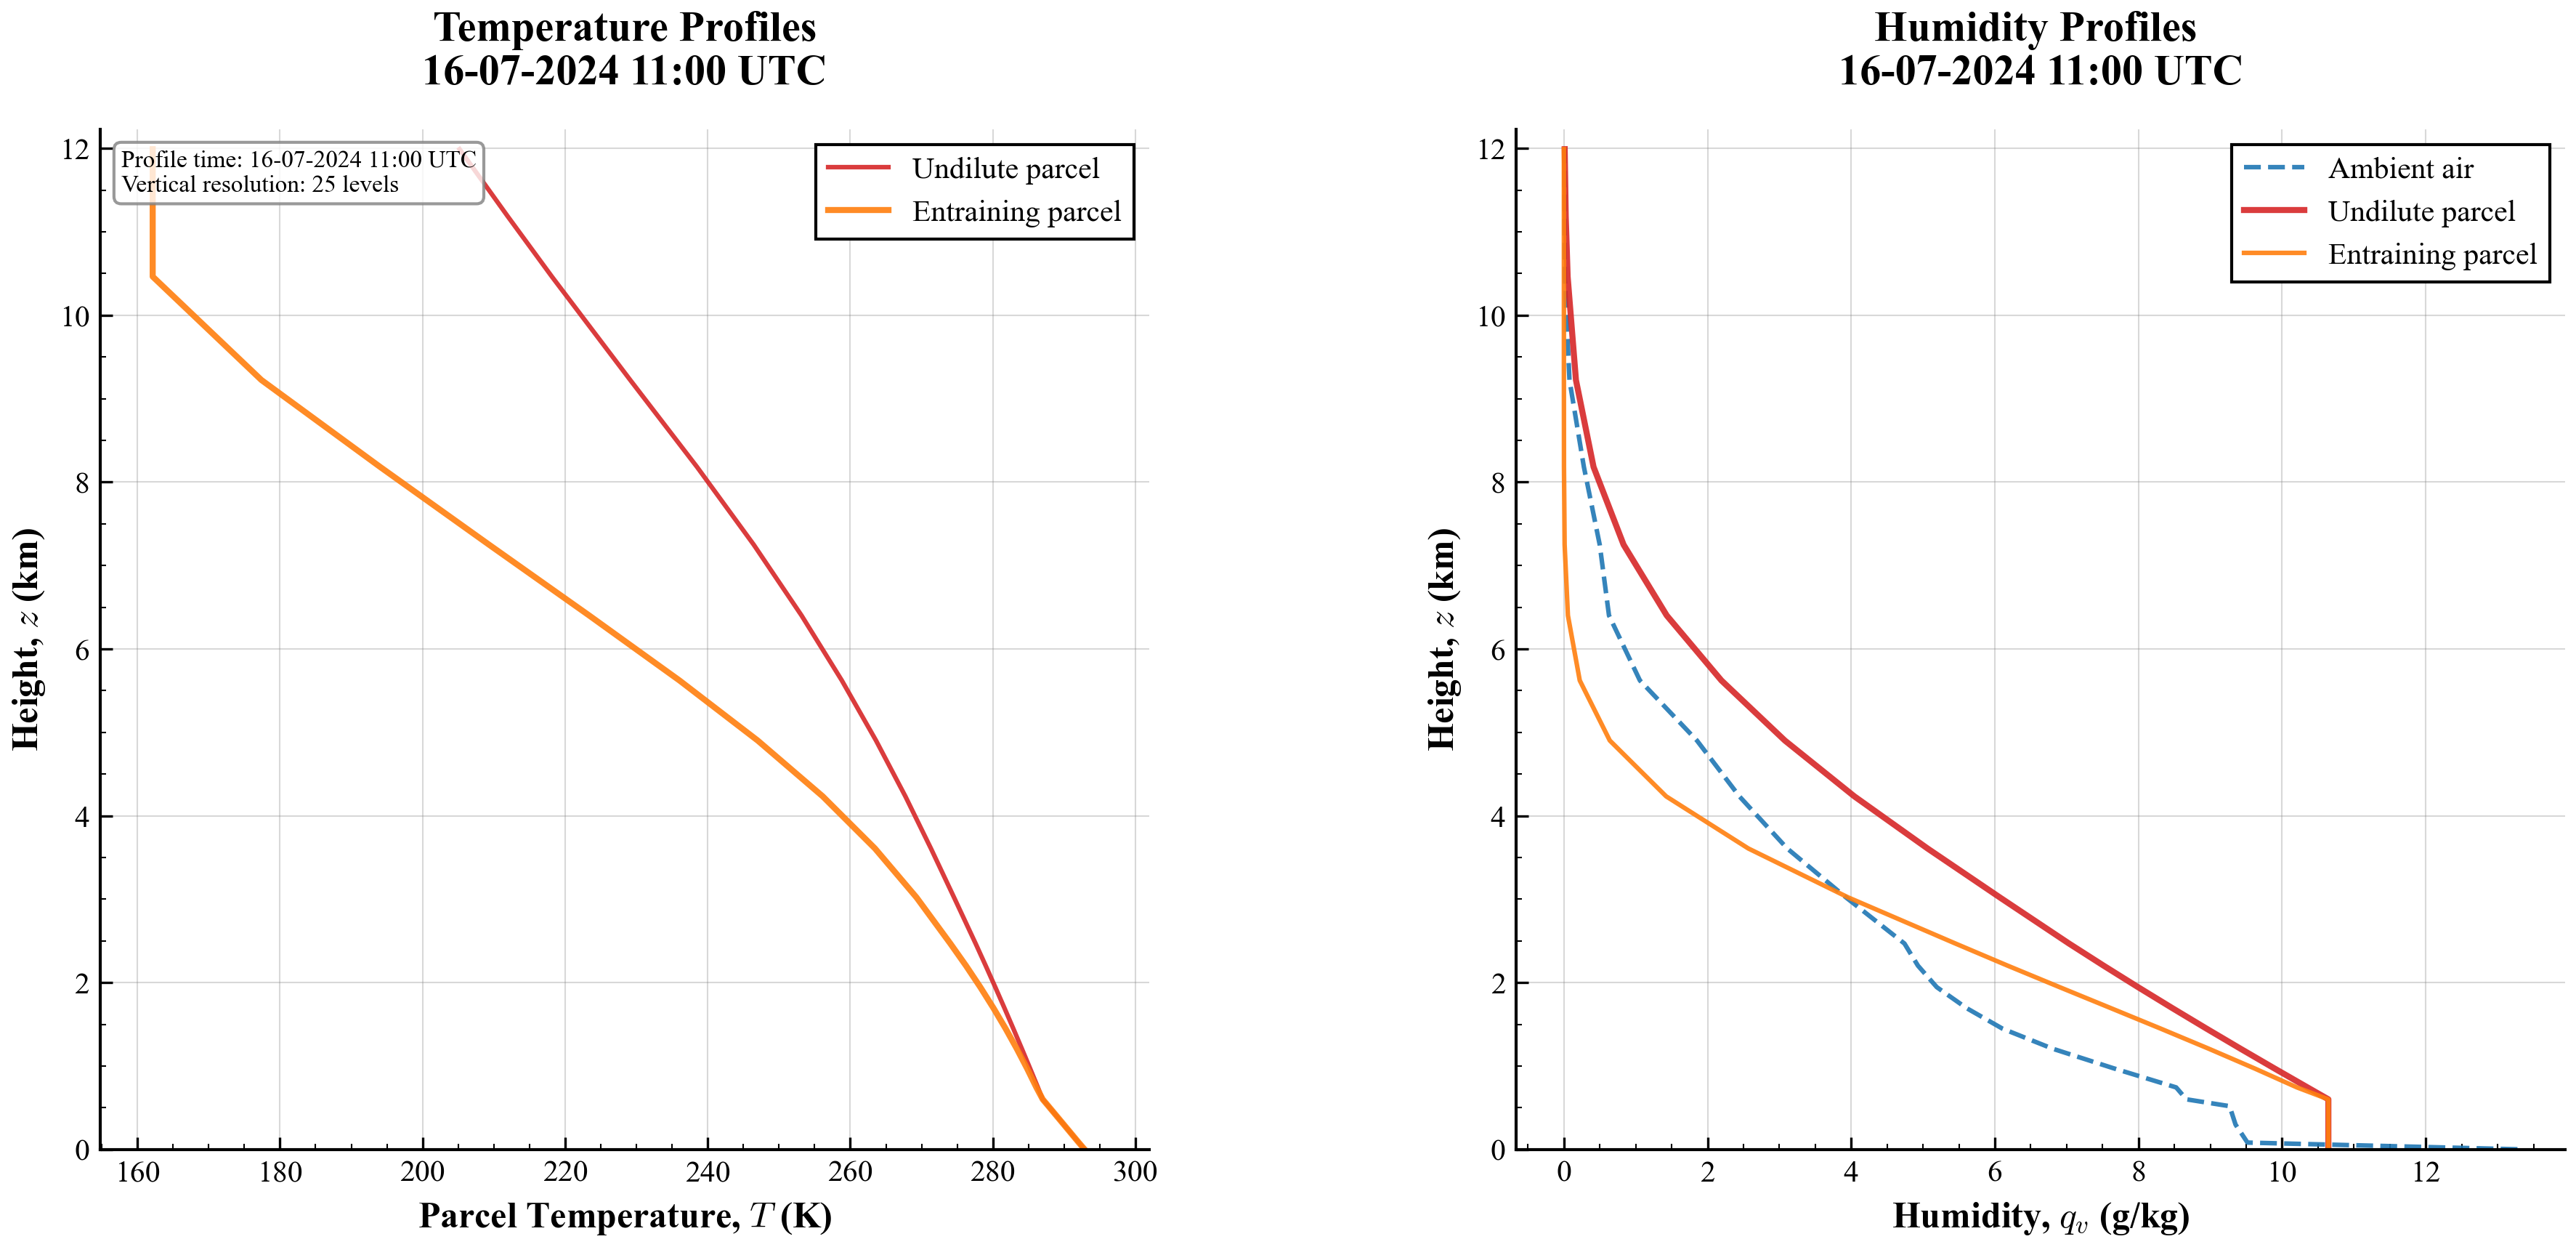

In [ ]:
index_2 = 11
import pandas as pd
import numpy as np

# Scientific publication-quality styling
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines
    'axes.linewidth': 1.0,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'xtick.minor.size': 2,
    'ytick.major.size': 4,
    'ytick.minor.size': 2,
    'xtick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.major.width': 0.8,
    'ytick.minor.width': 0.5,
    
    # Legend
    'legend.fontsize': 10,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))  # Two subplots side by side

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')

# ===== LEFT SUBPLOT (ax1) =====
# Plot with scientific line styles and markers
line_ambient1 = ax1.plot(temp_parcel[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['no_entrainment'], 
                        label='Undilute parcel', 
                        linewidth=1.5,
                        alpha=0.9)

line_dry1 = ax1.plot(T_parcel_new[index_2], Z_new[index_2]/1000,
                    color=colors['with_entrainment'], 
                    label='Entraining parcel',
                    linewidth=2.0,
                    alpha=0.9)

# Scientific axis labels with units
ax1.set_xlabel('Parcel Temperature, $T$ (K)', fontweight='bold')
ax1.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax1.set_title(f'Temperature Profiles\n{timestamp_str}',
              fontweight='bold', pad=15)

# Scientific grid
ax1.grid(True, alpha=0.3, linewidth=0.5, color='gray')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Set axis limits with some padding for scientific presentation
temp_range1 = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
               np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding1 = (temp_range1[1] - temp_range1[0]) * 0.05
ax1.set_xlim(temp_range1[0] - temp_padding1, temp_range1[1] + temp_padding1)

height_max1 = Z_new[index_2].max()/1000
ax1.set_ylim(0, height_max1 * 1.02)

# Scientific legend positioning
legend1 = ax1.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5,
                    ncol=1)

# ===== RIGHT SUBPLOT (ax2) - Duplicate =====
# Plot with scientific line styles and markers
line_ambient2 = ax2.plot(1000*q_v_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['ambient'], 
                        label='Ambient air',
                        linestyle='--', 
                        linewidth=1.5,
                        alpha=0.9)

line_dry2 = ax2.plot(1000*q_v_parcel[index_2], Z_new[index_2]/1000,
                    color=colors['no_entrainment'], 
                    label='Undilute parcel',
                    linestyle='-', 
                    linewidth=2.0,
                    alpha=0.9)
line_moist = ax2.plot(1000*q_v_parcel_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['with_entrainment'], 
                        label='Entraining parcel',
                        linestyle='-', 
                        linewidth=1.5,
                        alpha=0.9)
# Scientific axis labels with units
ax2.set_xlabel('Humidity, $q_v$ (g/kg)', fontweight='bold')
ax2.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax2.set_title(f'Humidity Profiles \n{timestamp_str}',
              fontweight='bold', pad=15)

# Scientific grid
ax2.grid(True, alpha=0.3, linewidth=0.5, color='gray')
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Add horizontal reference lines with labels

height_max2 = Z_new[index_2].max()/1000
ax2.set_ylim(0, height_max2 * 1.02)

# Scientific legend positioning
legend2 = ax2.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5,
                    ncol=1)

# Professional tick formatting for both subplots
for ax in [ax1, ax2]:
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')
    
    # Ensure scientific notation if needed
    from matplotlib.ticker import ScalarFormatter
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# Adjust spacing manually instead of tight_layout to preserve subplot spacing
plt.subplots_adjust(left=0.08, right=0.95, top=0.9, bottom=0.12, wspace=0.35)

# Optional: Add metadata text box for scientific context - only on left subplot
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=8,
         verticalalignment='top', bbox=props)

# Show the plot
plt.show()
# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

In [ ]:
len(Z_new[index_2])

25

#### Cloud top and base

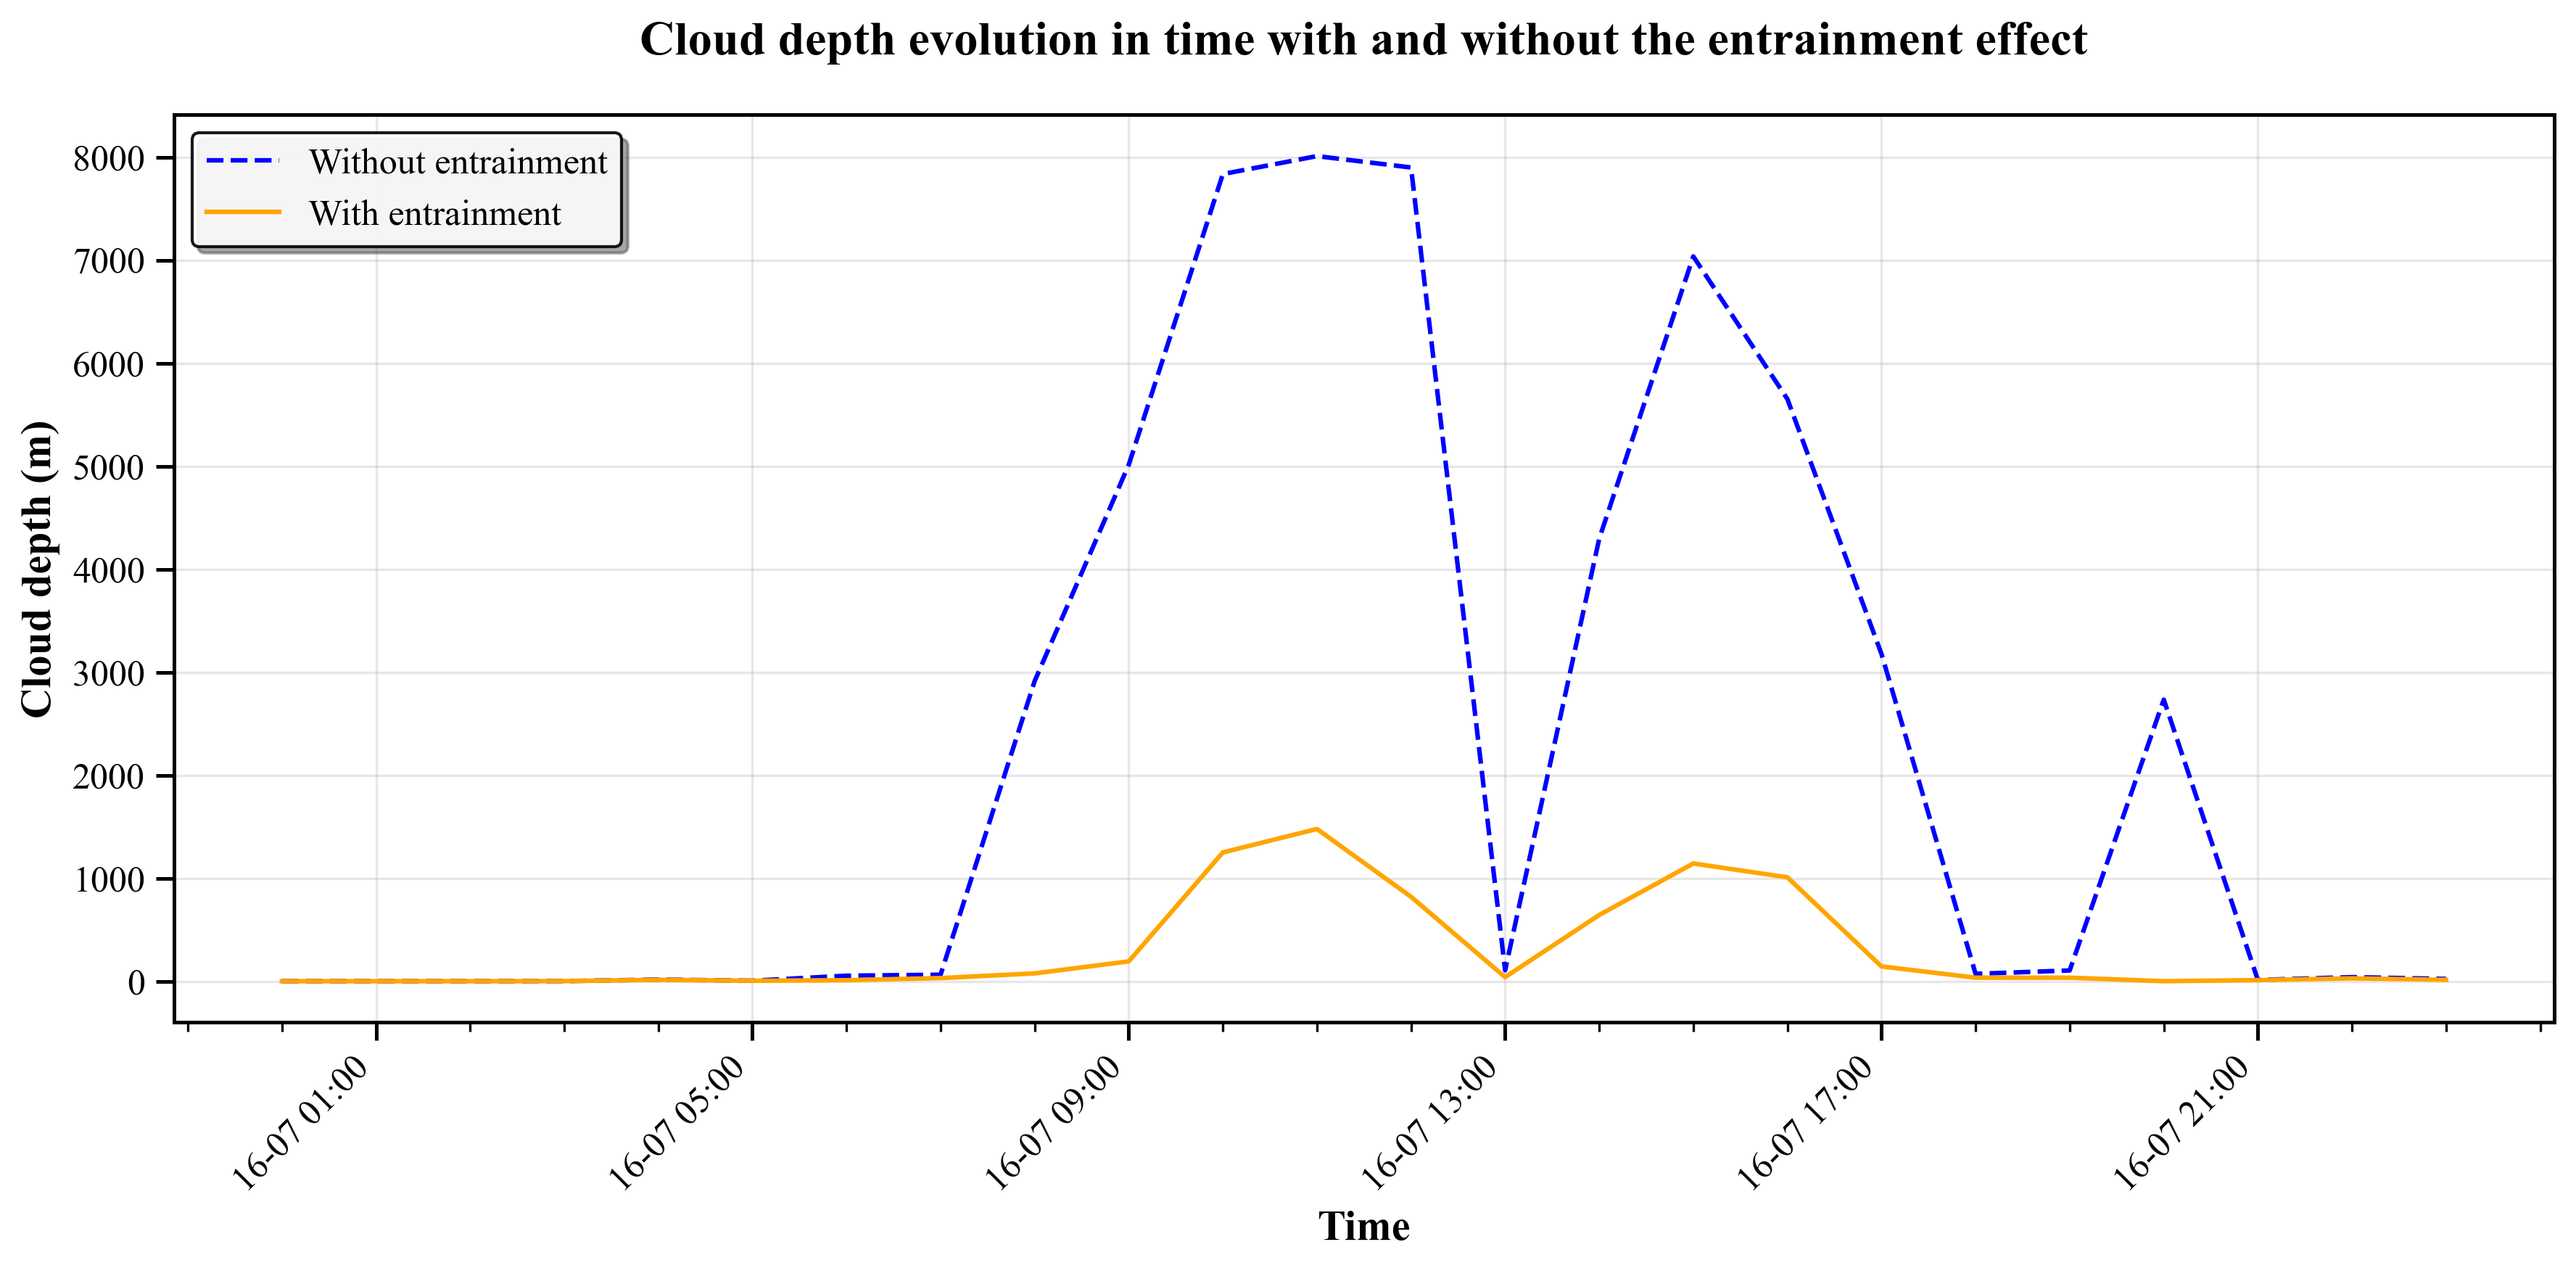

In [ ]:
import pandas as pd
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})
import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

fig, ax = plt.subplots(figsize=(12, 6))  # Slightly wider figure
ax.plot(time_dt, np.maximum(0, Z_t - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='blue', label='Without entrainment',linestyle='--')
ax.plot(time_dt, np.maximum(0, Z_t_new - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='orange', label='With entrainment')

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))  # Every 4 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))   # Minor ticks every hour

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Rest of your styling code...
ax.set_ylabel('Cloud depth (m)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud depth evolution in time with and without the entrainment effect',
             fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)

# Improved legend
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

plt.tight_layout()

#### Updraft velocity

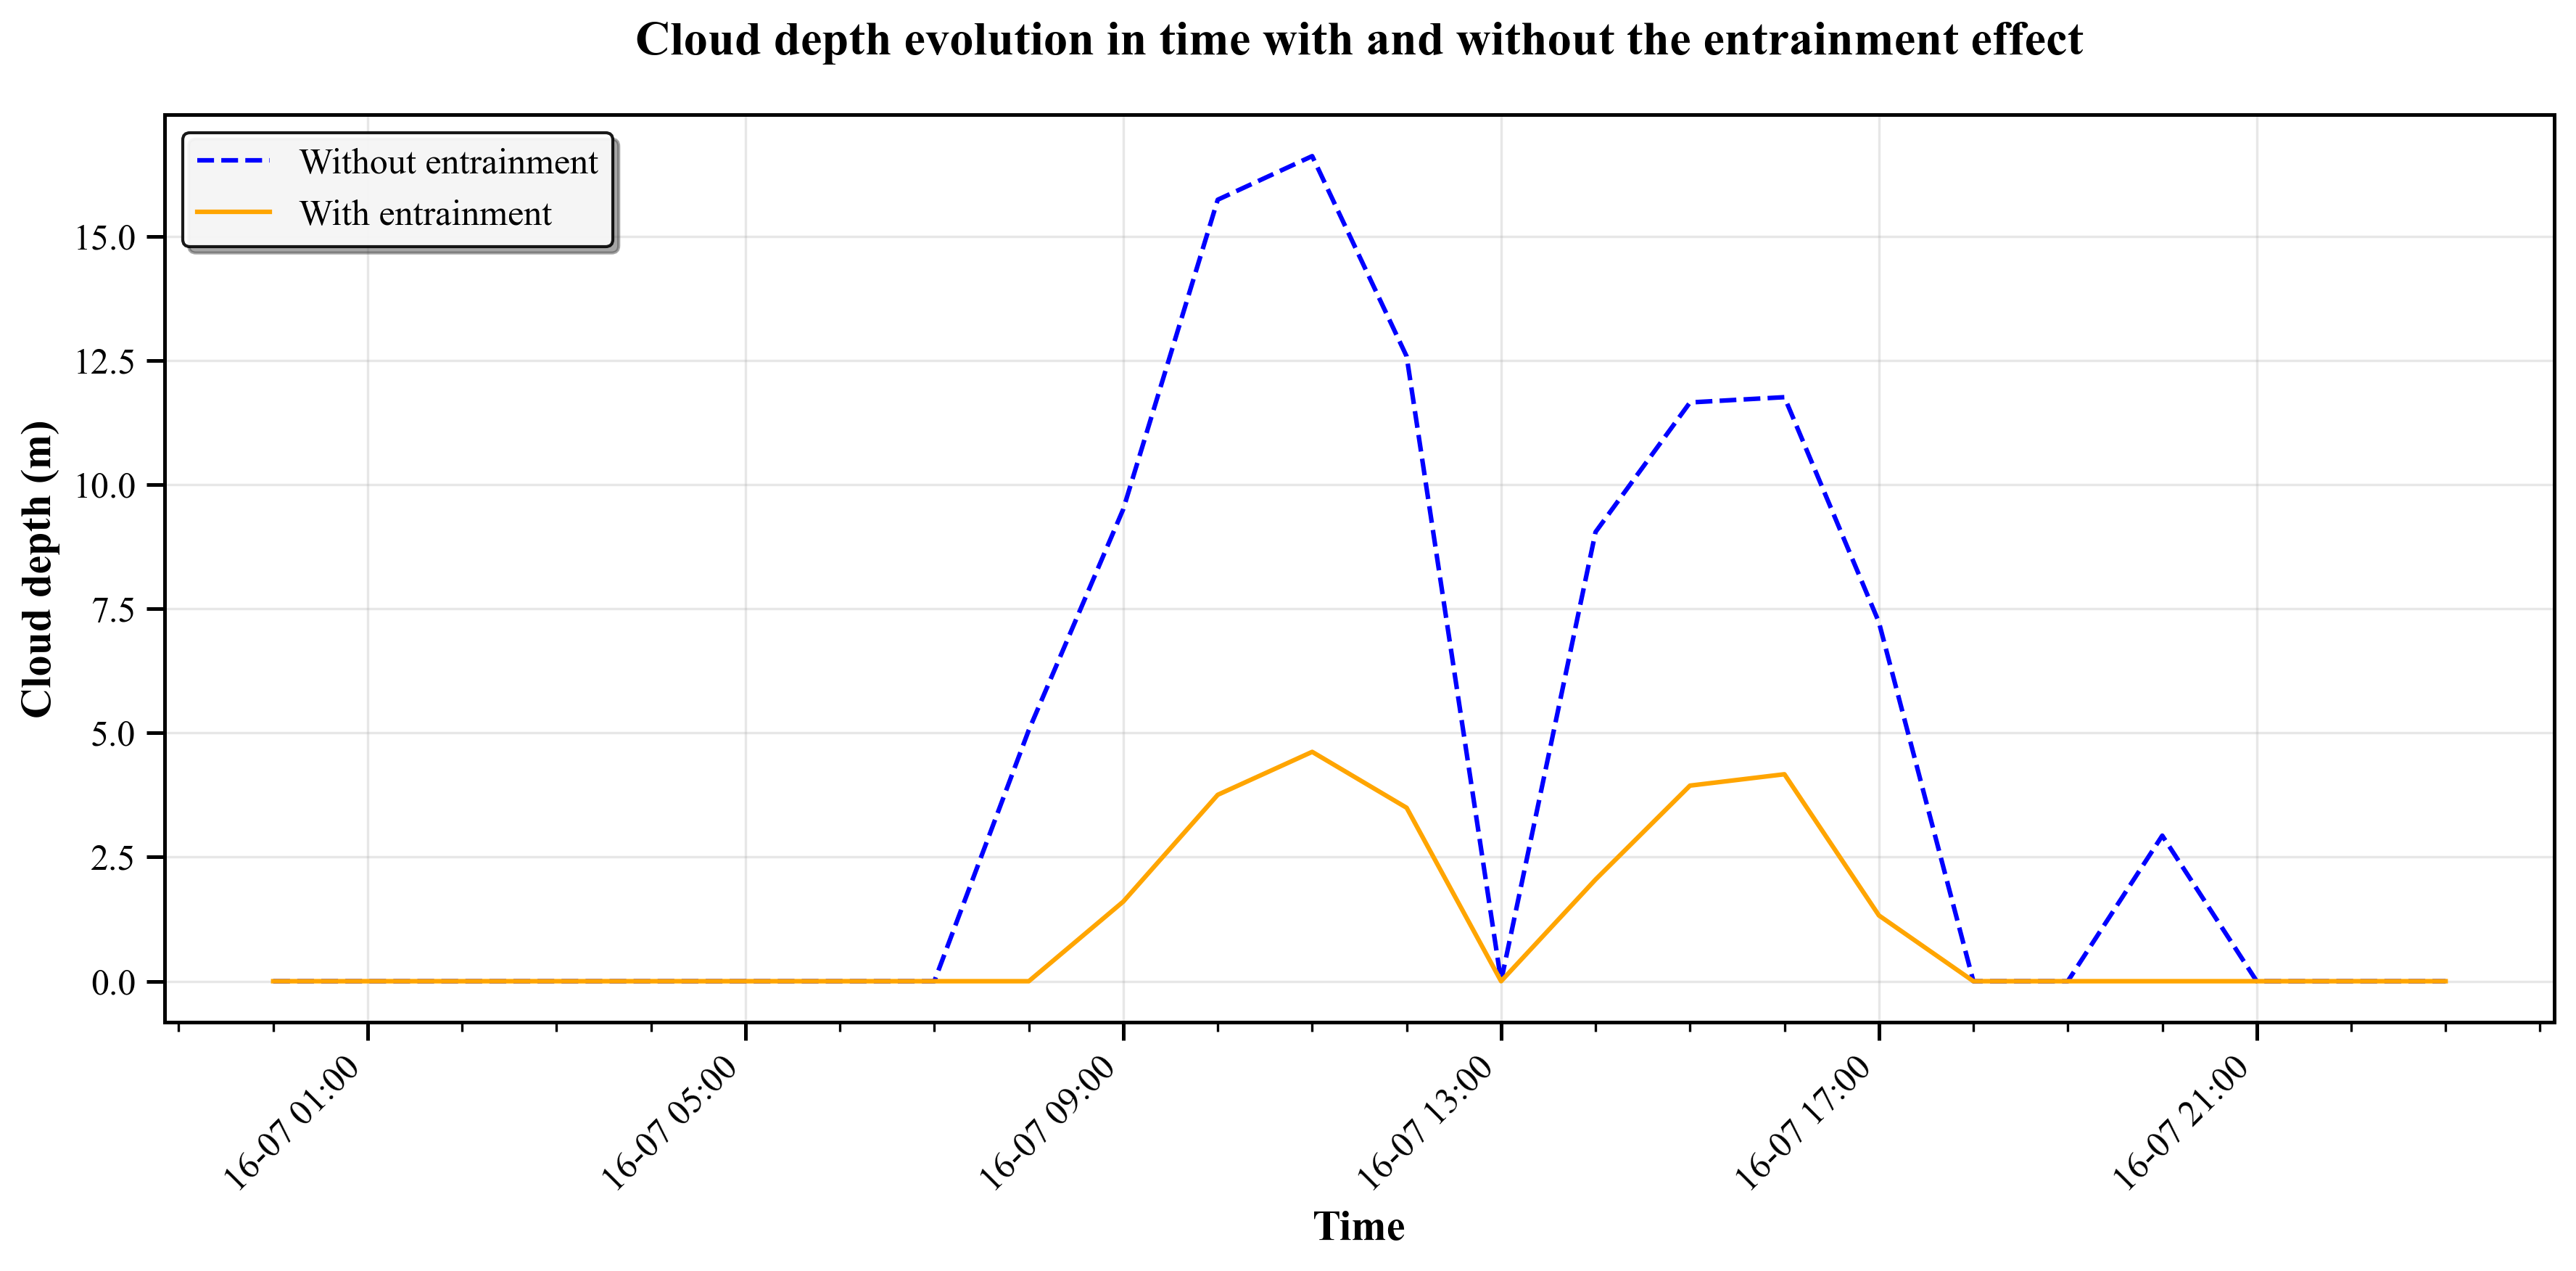

In [ ]:


plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})
import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

fig, ax = plt.subplots(figsize=(12, 6))  # Slightly wider figure
ax.plot(time_dt, w_parcel_max_old/2,
        color='blue', label='Without entrainment',linestyle='--')
ax.plot(time_dt, w_parcel_max/2,
        color='orange', label='With entrainment')

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))  # Every 4 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))   # Minor ticks every hour

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Rest of your styling code...
ax.set_ylabel('Cloud depth (m)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud depth evolution in time with and without the entrainment effect',
             fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.set_axisbelow(True)

# Improved legend
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

plt.tight_layout()
#plt.figure(figsize=(12,6))
#plt.plot(time,w_parcel_max/2,linewidth=0.7)
#plt.plot(time,w_parcel_max_old/2,linewidth=0.7)
#plt.ylabel('Average Updraft velocity (m/s)')
#plt.xlabel(('Date (MM-DD) - Time (HH)'))

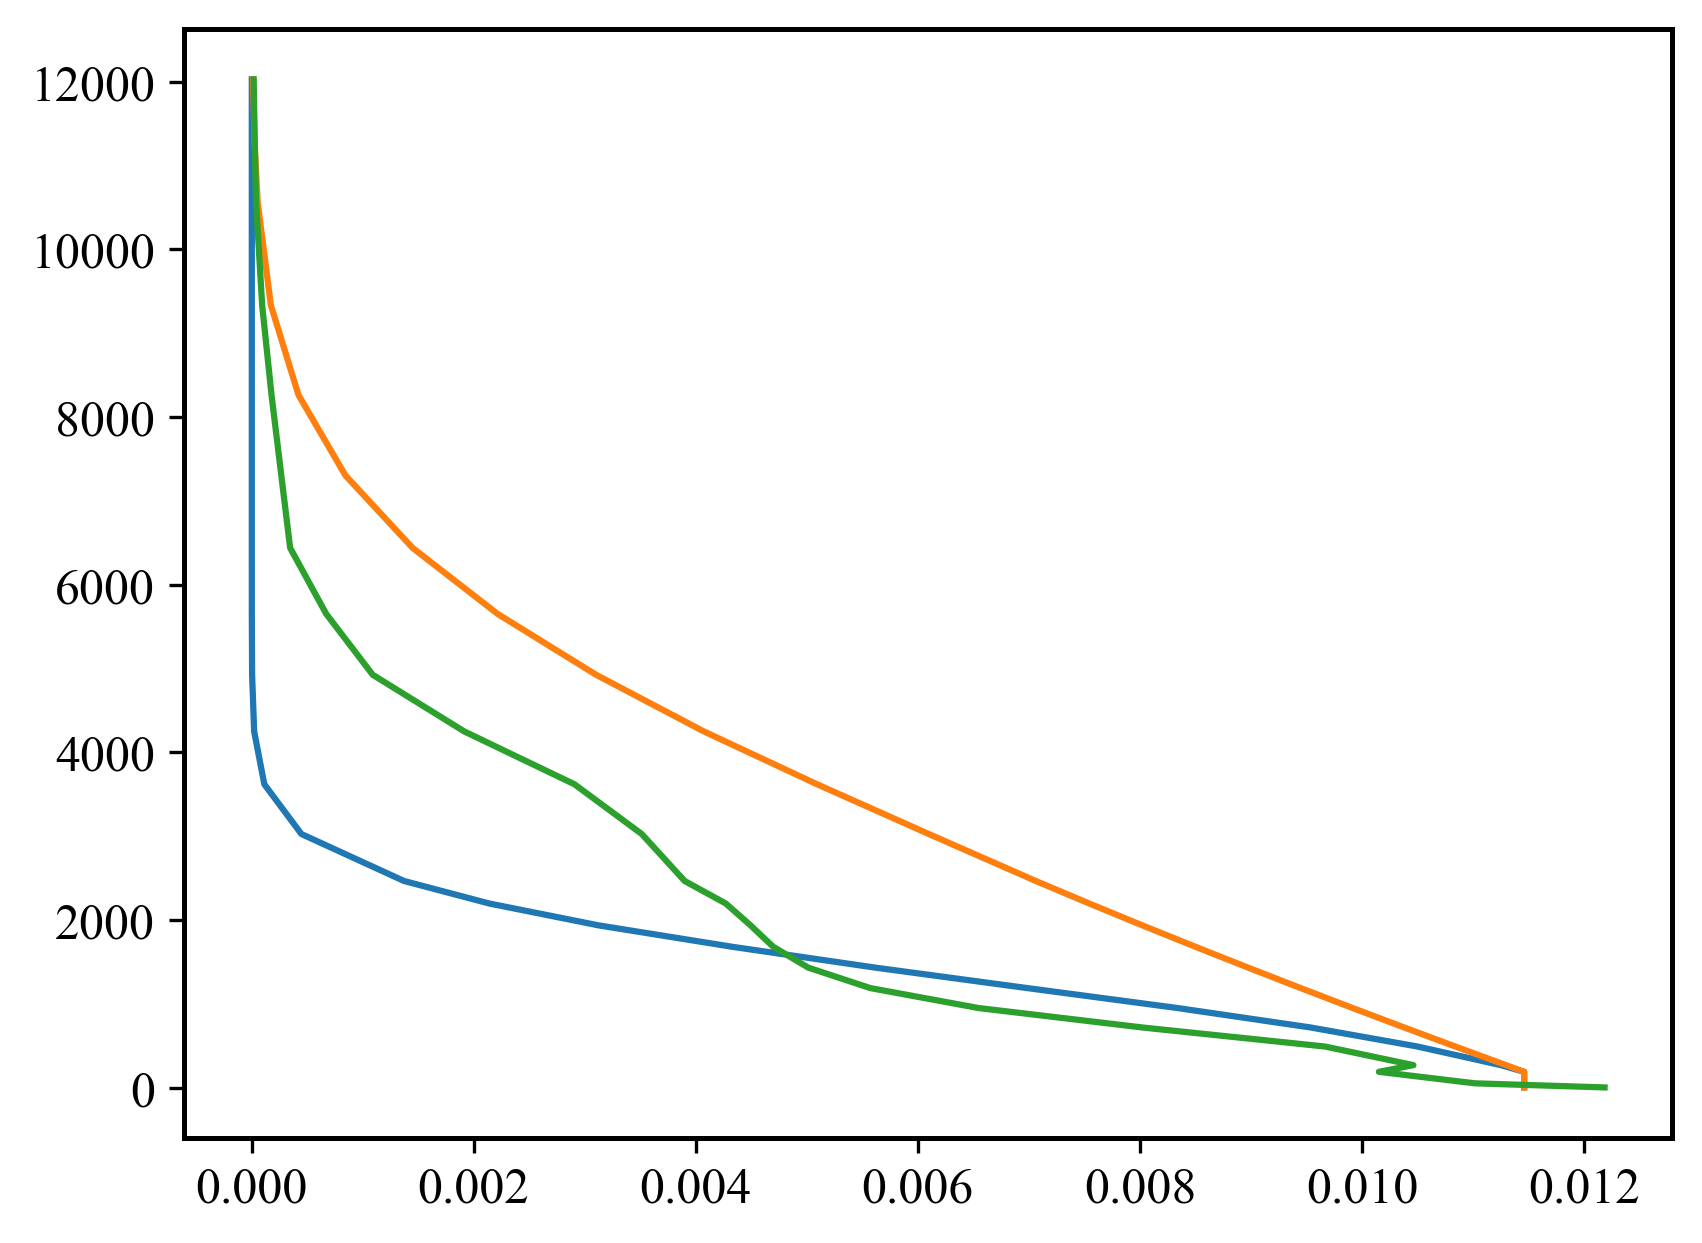

In [ ]:
index = 2
#plt.plot(w_sat(T_d[index],p_new[index,0]) - q_v_parcel[index],Z_new[index],label='T_v_moist')
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_l'   )
plt.plot(q_v_parcel[index],Z_new[index],label='q_v_parcel')
plt.plot(q_v_new[index],Z_new[index],label='q_v')

#### LWC and LWP(state)

Text(0.5, 0, 'Time')

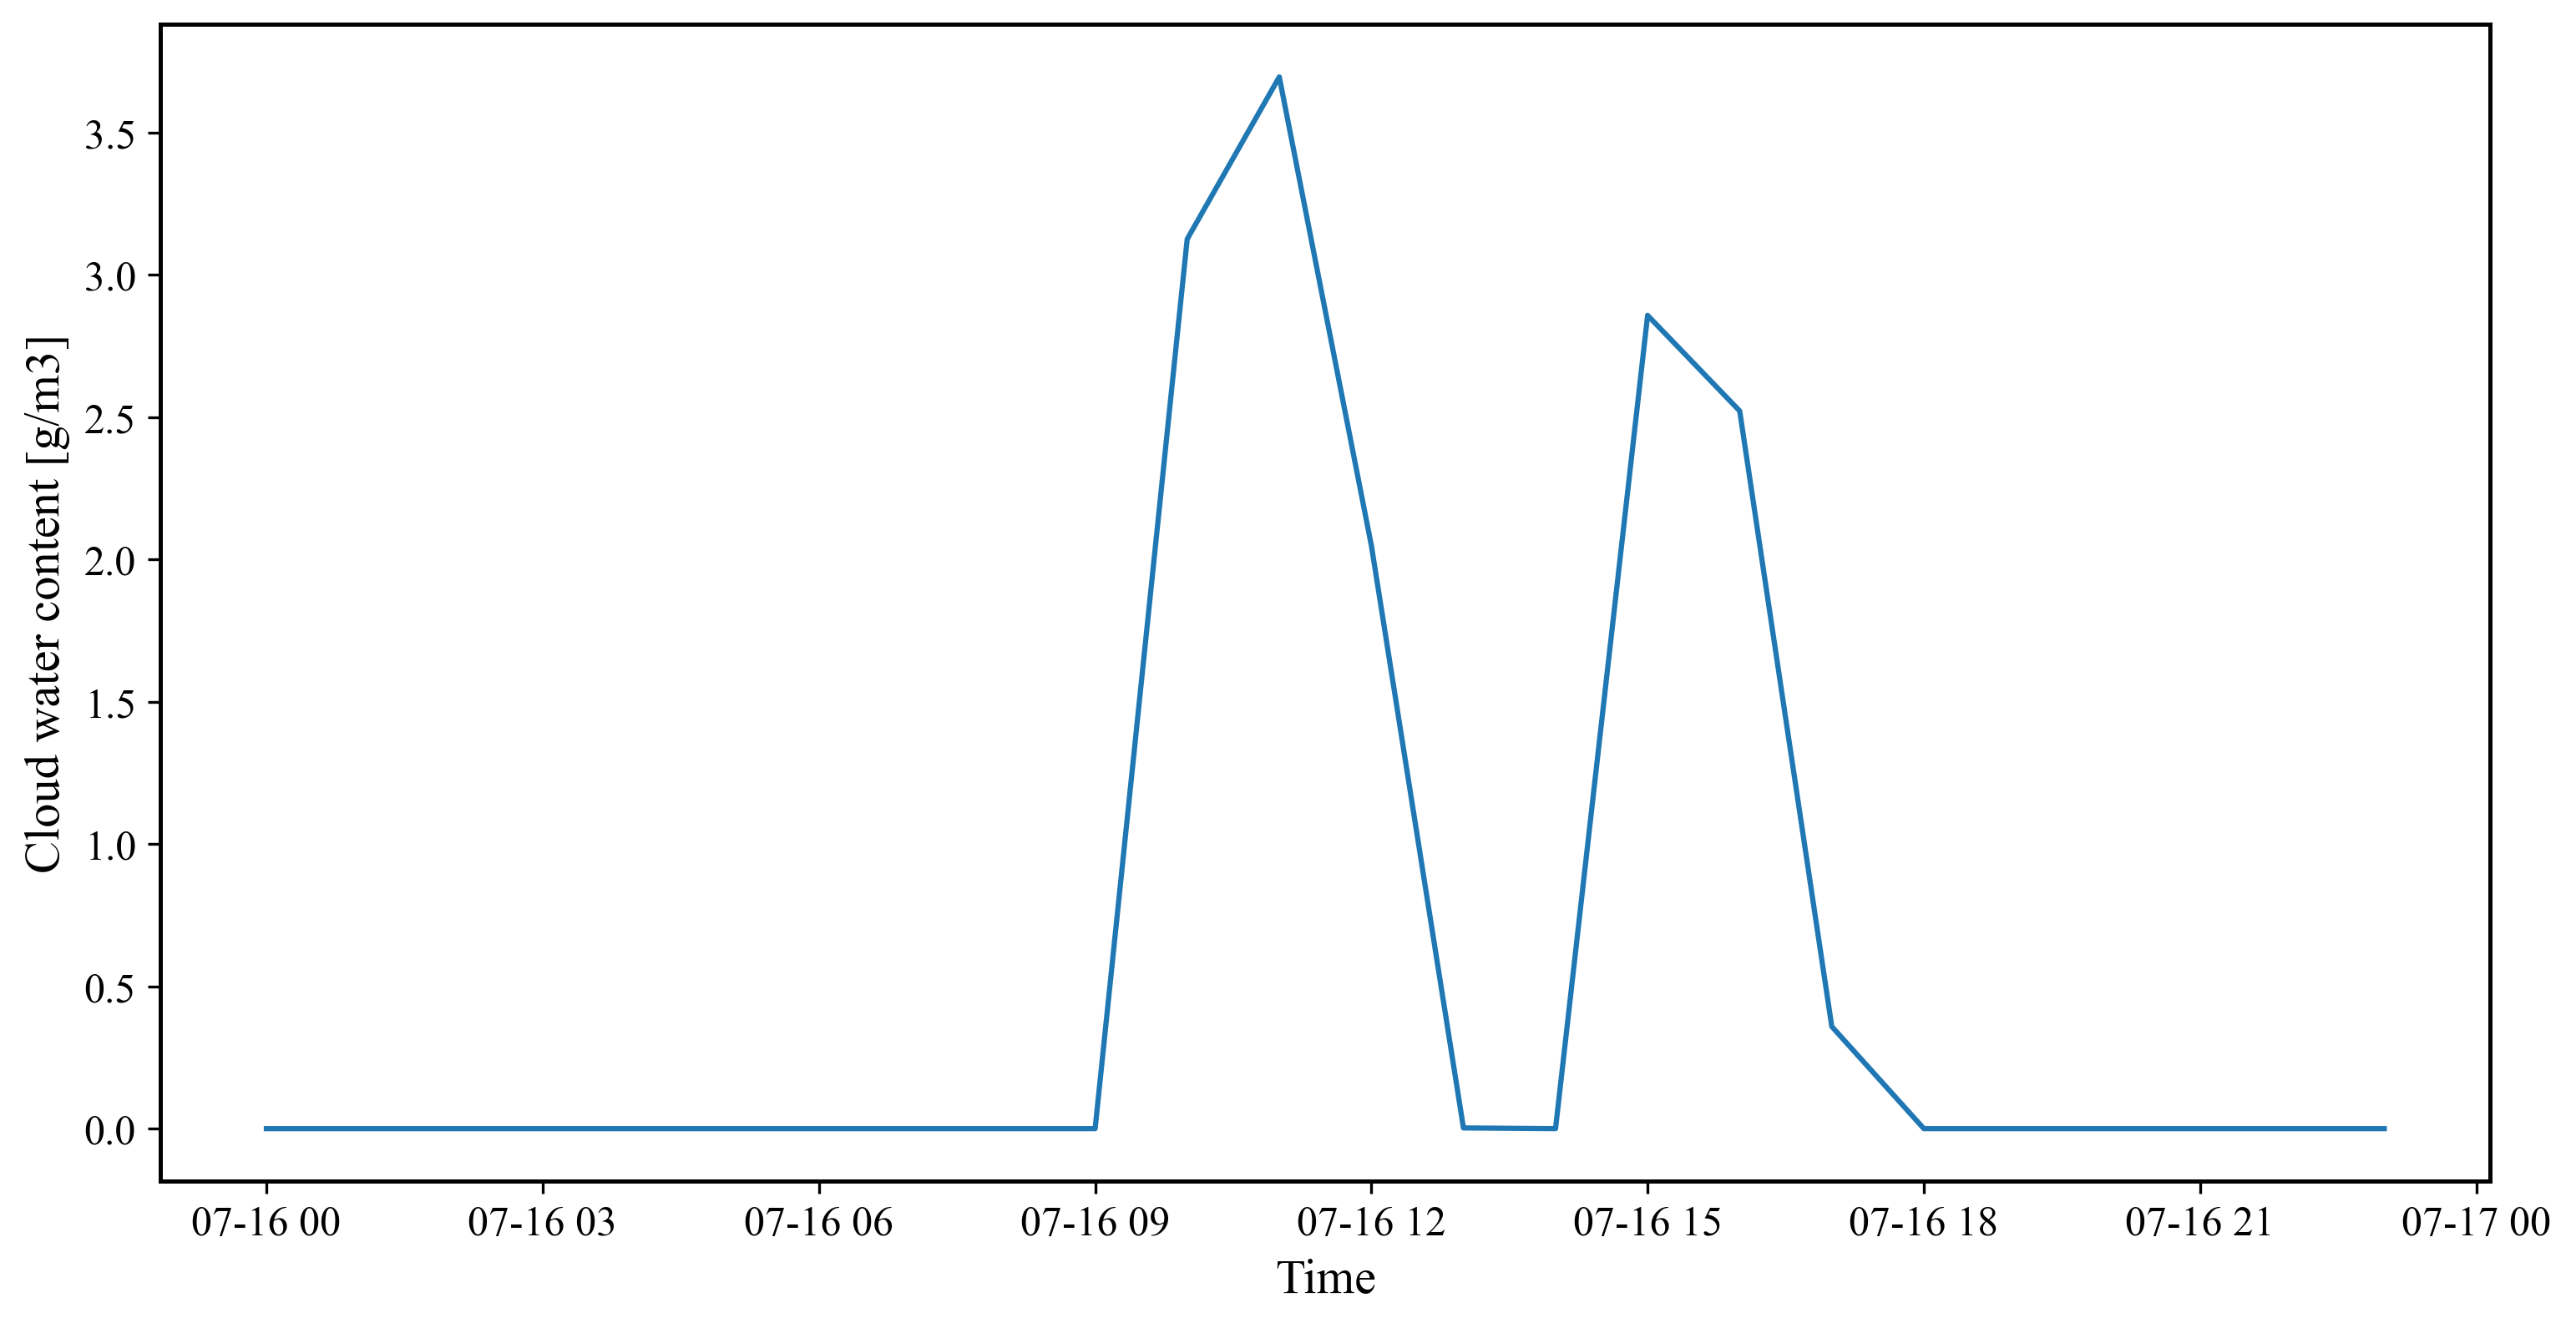

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(time,R*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
#plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

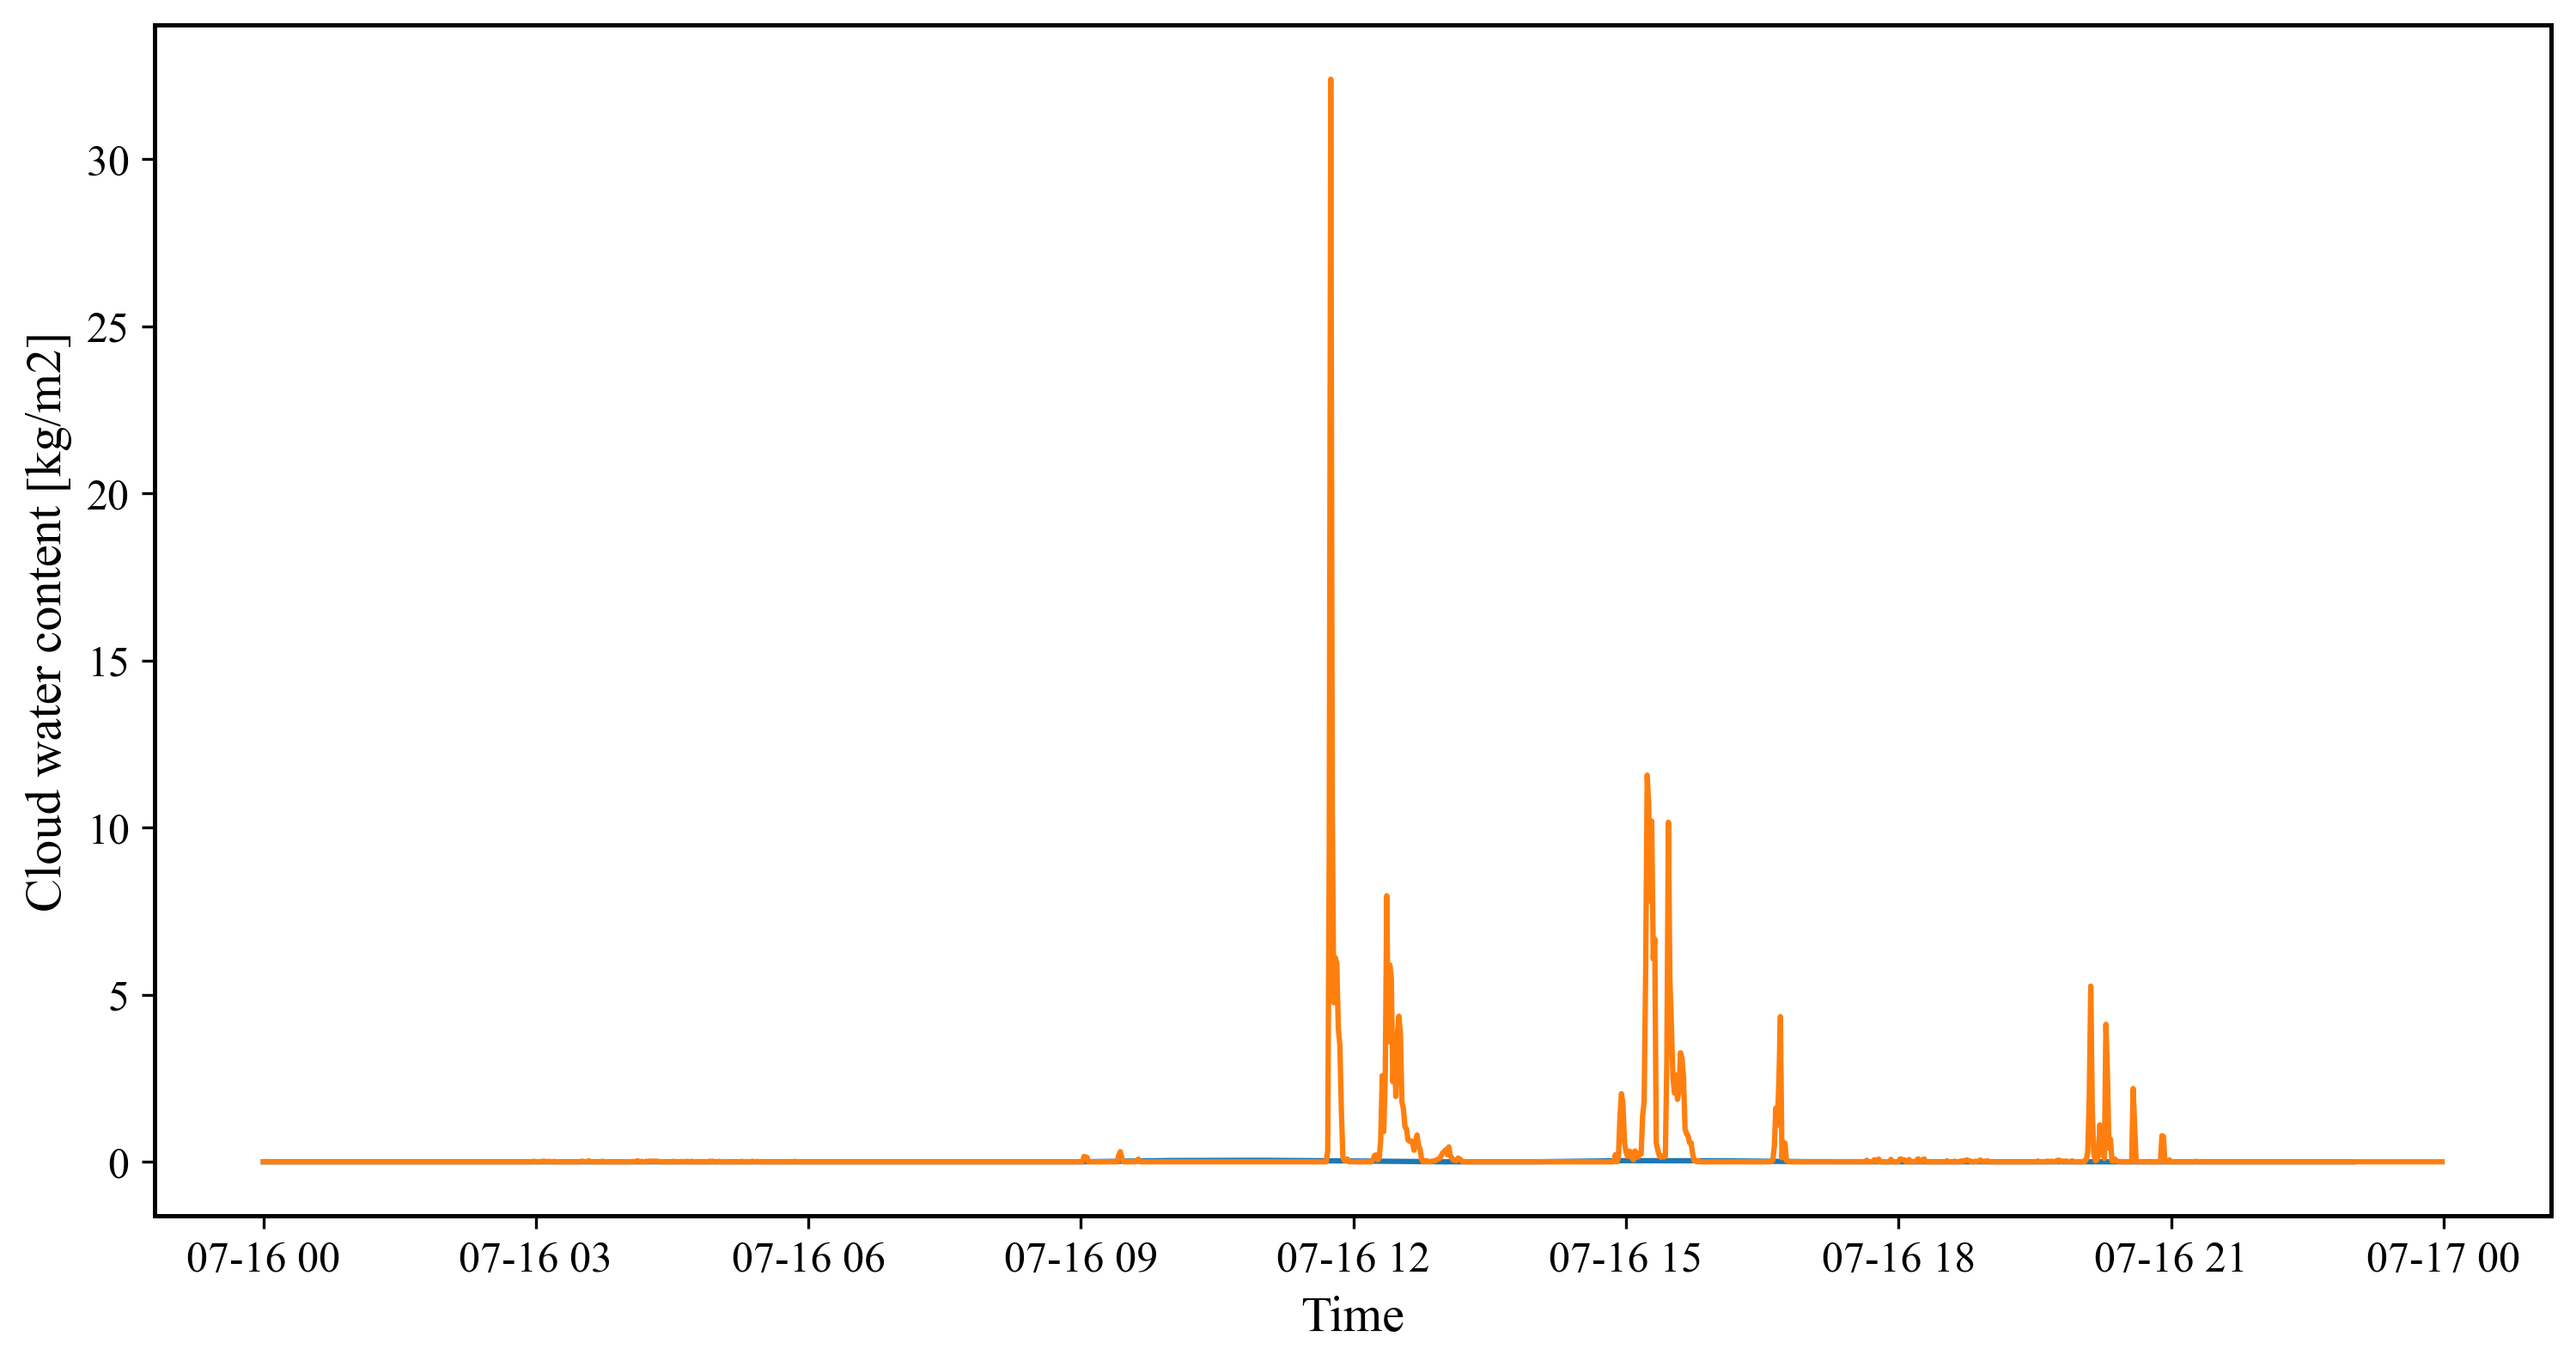

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(time,X/100)
plt.plot(rain_rate.time,rain_rate)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

In [ ]:
from scipy import stats
stats.pearsonr(R[1:]*3600, hourly_avg[0:-1])

PearsonRResult(statistic=0.3490166673711936, pvalue=0.10261995073254511)

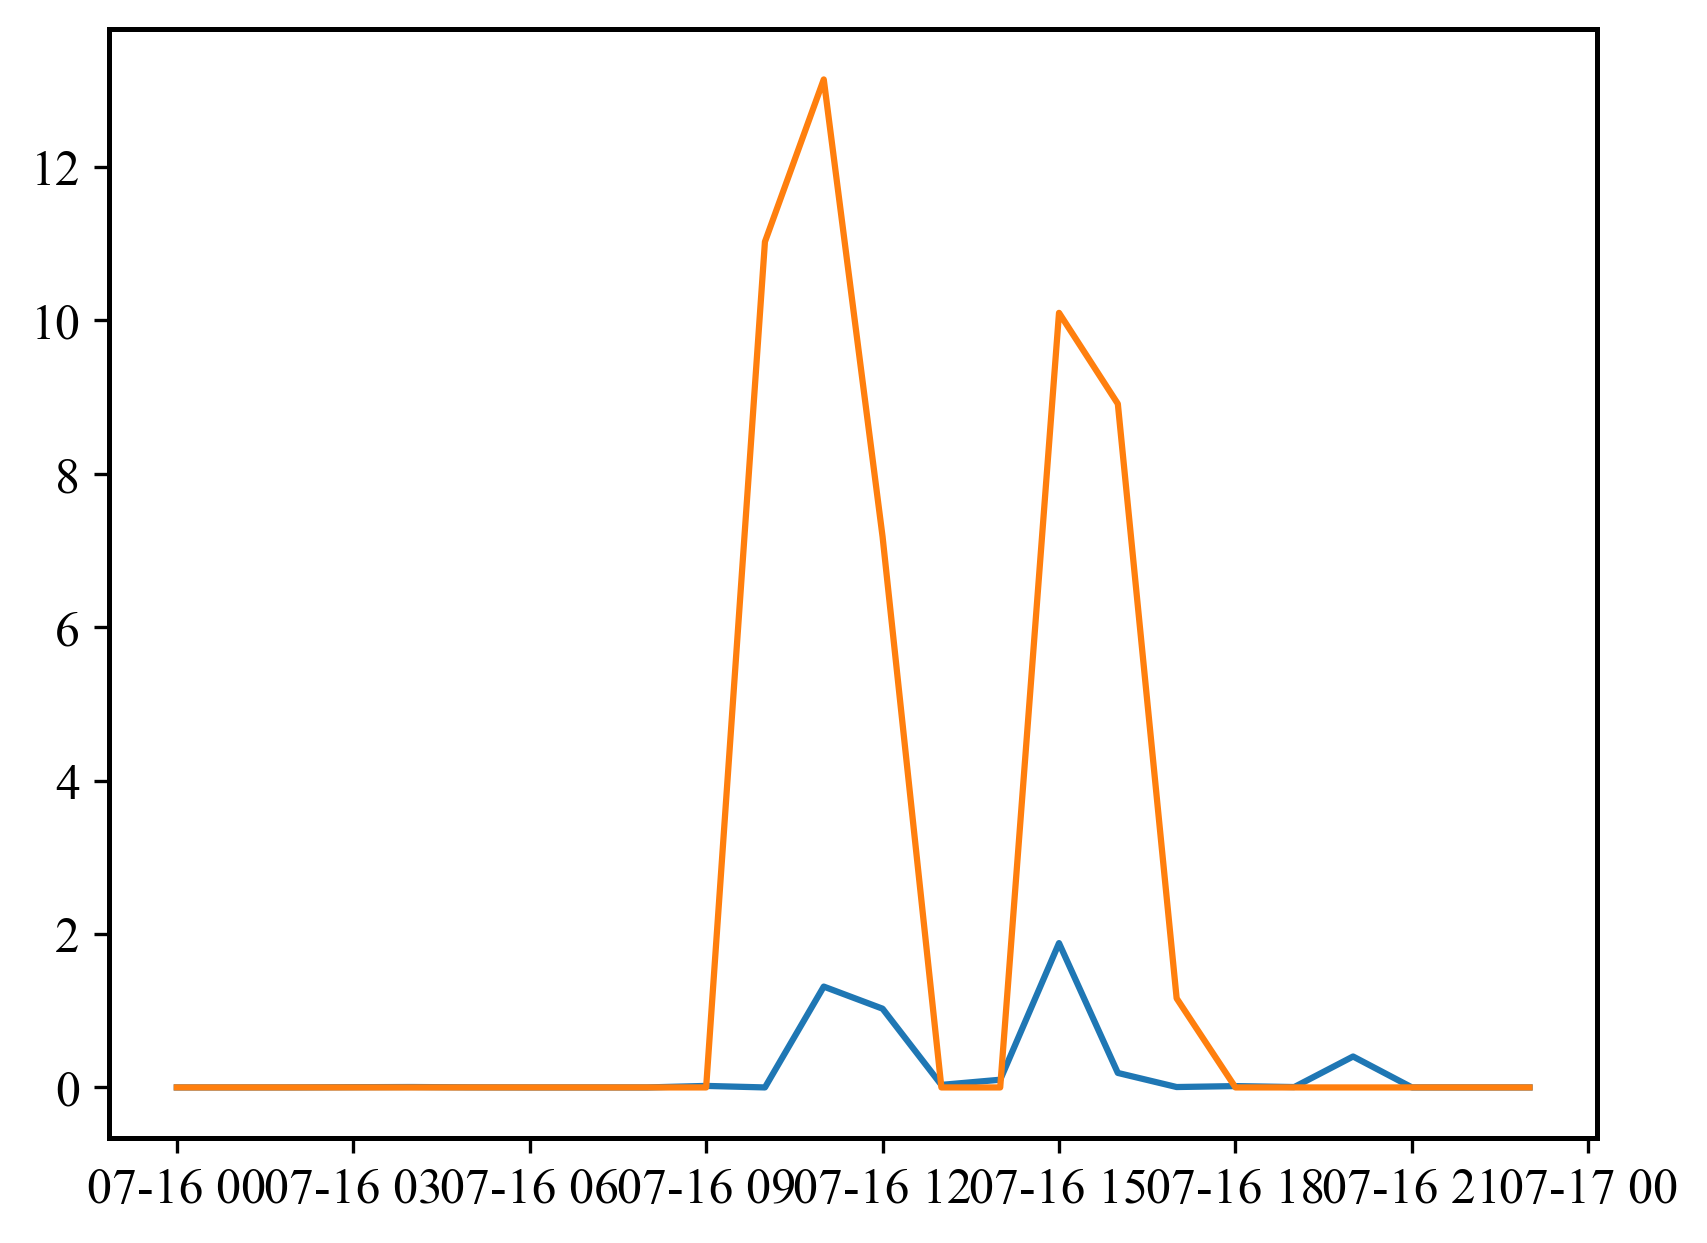

In [ ]:
plt.plot(time,hourly_avg)
plt.plot(time,P*3600)
#plt.plot(time,R_old*3600)

In [ ]:
p_s

array([98875.37090616, 98734.30829884, 98397.3364903 , 98273.47570927,
       98100.32683983, 97622.3247724 , 96618.24351472, 95761.23548756,
       94306.13765983, 93286.86982656, 93585.03549935, 94070.462743  ,
       94540.1268939 , 96345.809627  , 96228.92968365, 94823.48300141,
       94343.03860087, 94402.05452005, 95896.57152017, 96262.42582013,
       97143.78646852, 97947.3731785 , 98284.08676626, 98656.15492748])

#### Size distribution

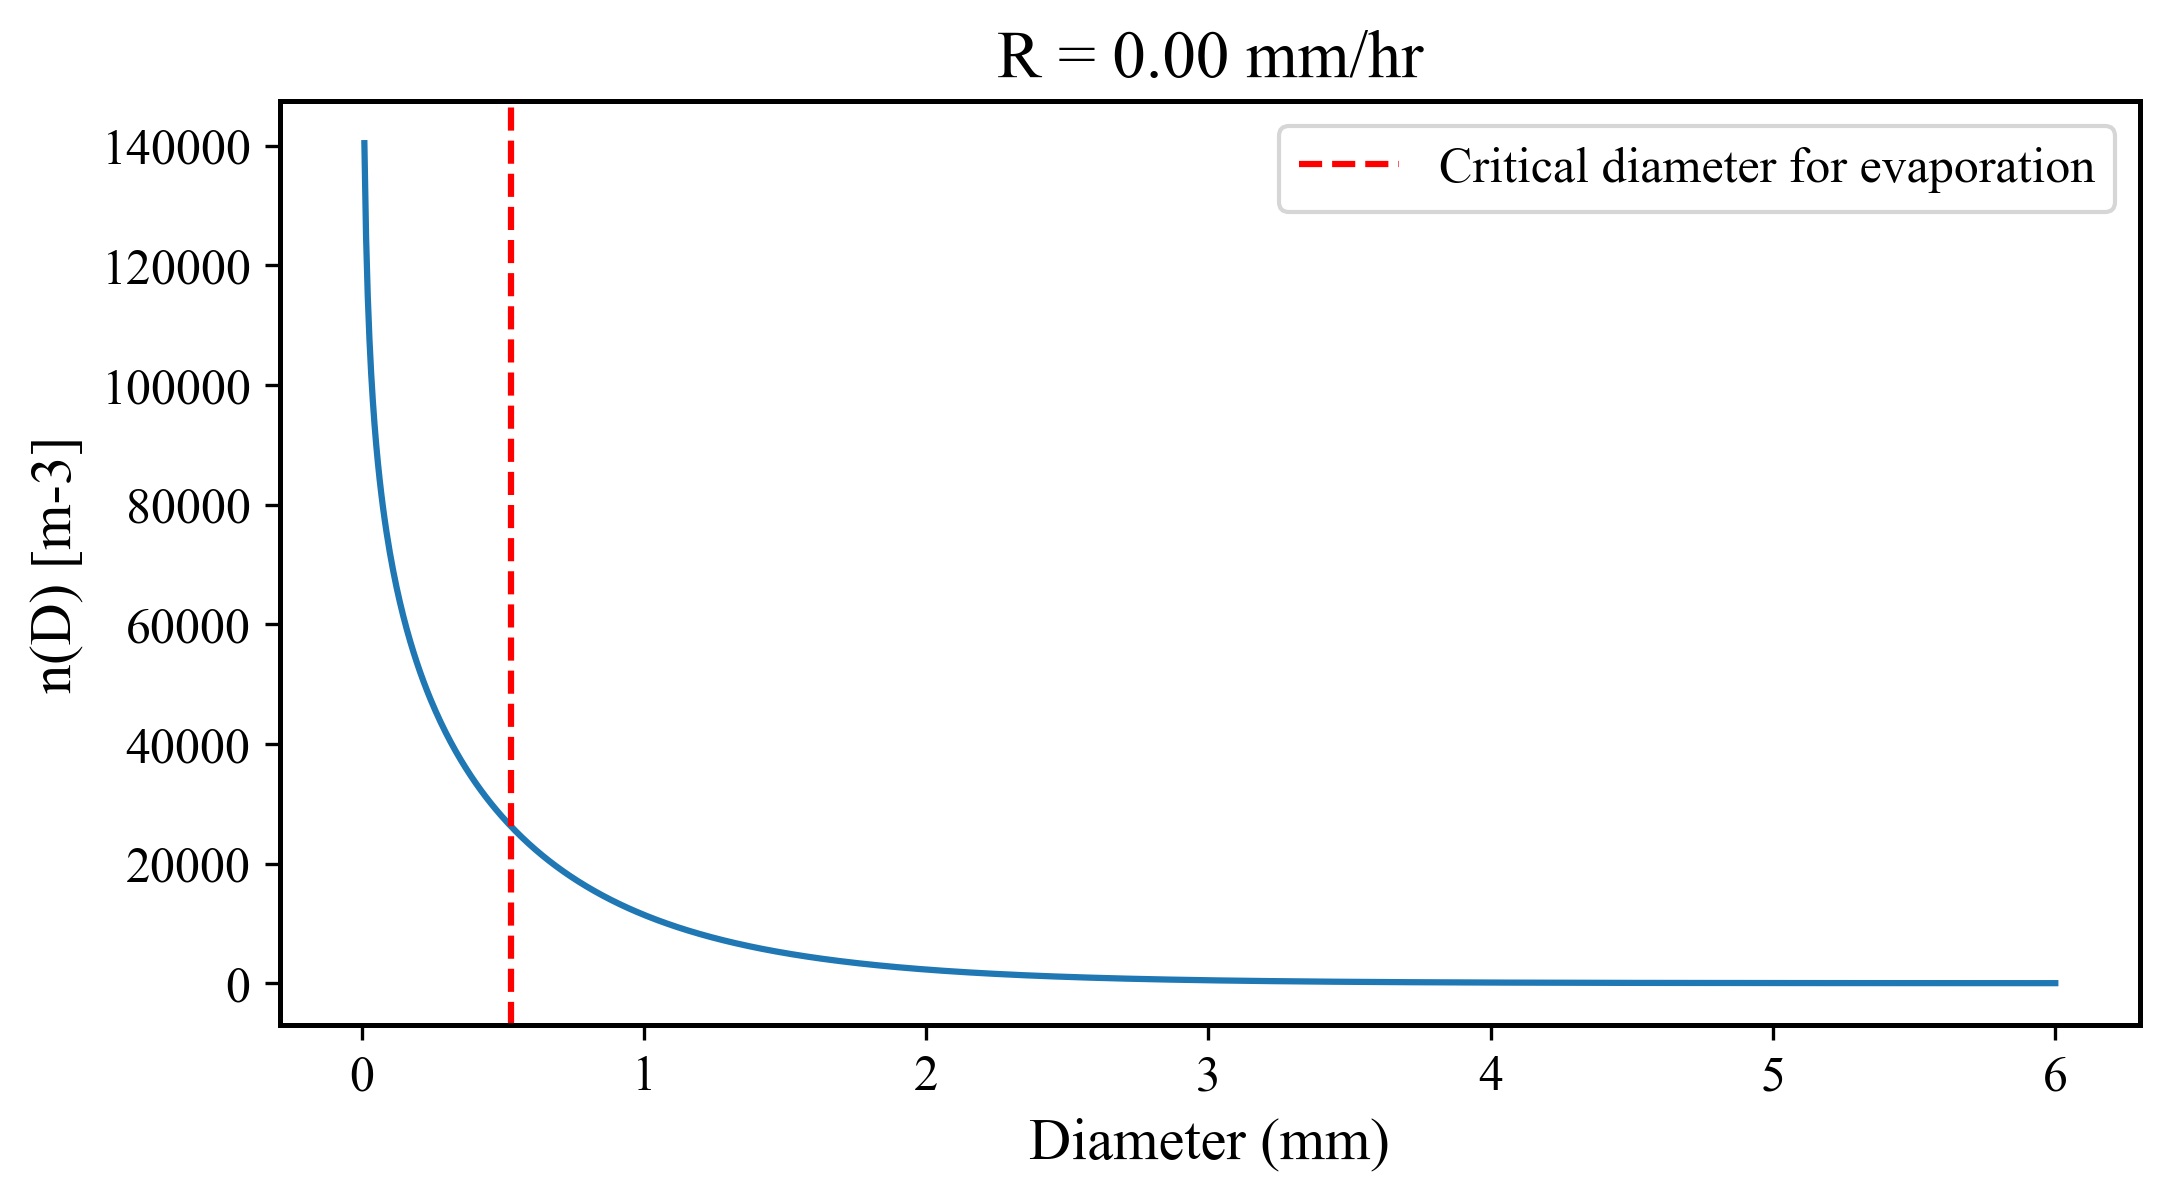

In [ ]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()